# Data Understanding

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load Dataset
file_path = ('/content/drive/MyDrive/File Pelatihan/Rakamin Virtual Internship Data Scientist - ID X /loan_data_2007_2014.csv')
df = pd.read_csv(file_path)

/tmp/ipython-input-2102901583.py:3: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [ ]:
#Memanggil Data
print("Jumlah Baris kolom:", df.shape)
df.head()

Jumlah Baris kolom: (466285, 75)


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Cek Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

##Memeriksa apakah setiap baris data mewakili individu

In [ ]:
#Mengecek jumlah nilai unik pada kolom id dan kolom identitas individu (member_id)
jumlah_baris = df['id'].nunique()
jumlah_unik = df['member_id'].nunique()

In [ ]:
#Cek apakah setiap baris mewakili satu individu
if jumlah_baris == jumlah_unik:
    print("Setiap baris mewakili satu individu.")
else:
    print("Tidak setiap baris mewakili satu individu.")

Setiap baris mewakili satu individu.


In [ ]:
print("Jumlah Baris:", jumlah_baris)
print("Jumlah Unik:", jumlah_unik)

Jumlah Baris: 466285
Jumlah Unik: 466285


#Features Engineering

In [ ]:
#Identifikasi kolom yang tidak digunakan
cools_to_drop = [
    #unique id
    'Unnamed: 0',
    'id',
    'member_id',

    #teks bebas
    'url',
    'desc',

    #Nilai kosong dan lainnya
    'zip_code',
    'annual_inc_joint',
    'dti_joint',
    'verification_status_joint',
    'open_acc_6m',
    'open_il_6m',
    'open_il_12m',
    'open_il_24m',
    'mths_since_rcnt_il',
    'total_bal_il',
    'il_util',
    'open_rv_12m',
    'open_rv_24m',
    'max_bal_bc',
    'all_util',
    'inq_fi',
    'total_cu_tl',
    'inq_last_12m',
    'mths_since_last_major_derog',
    'tot_coll_amt',
    'tot_cur_bal',
    'total_rev_hi_lim',
    'sub_grade'
]

In [ ]:
#Drop kolom yang tidak digunakan
df.drop(cools_to_drop, axis=1, inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 47 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   466285 non-null  int64  
 1   funded_amnt                 466285 non-null  int64  
 2   funded_amnt_inv             466285 non-null  float64
 3   term                        466285 non-null  object 
 4   int_rate                    466285 non-null  float64
 5   installment                 466285 non-null  float64
 6   grade                       466285 non-null  object 
 7   emp_title                   438697 non-null  object 
 8   emp_length                  445277 non-null  object 
 9   home_ownership              466285 non-null  object 
 10  annual_inc                  466281 non-null  float64
 11  verification_status         466285 non-null  object 
 12  issue_d                     466285 non-null  object 
 13  loan_status   

##Identifikasi Variabel Target

In [ ]:
#kolom yang digunakan 'loan_status
#Menghitung presentase distribusi nilai dalam bentuk presentase
presentase_loan_status = df['loan_status'].value_counts(normalize=True) * 100
print(presentase_loan_status)


loan_status
Current                                                48.087757
Fully Paid                                             39.619332
Charged Off                                             9.109236
Late (31-120 days)                                      1.479782
In Grace Period                                         0.674695
Does not meet the credit policy. Status:Fully Paid      0.426349
Late (16-30 days)                                       0.261214
Default                                                 0.178432
Does not meet the credit policy. Status:Charged Off     0.163205
Name: proportion, dtype: float64


In [ ]:
#Kelompak status pembayaran yang dianggap berbahaya
bad_loan_status = ['Charged Off',
                   'Default',
                   'Does not meet the credit policy. Status:Charged Off',
                   'Late (31-120 days)'
]
#Menambahkan kolom 'bad_loan_status'
df['bad_loan_status'] = np.where(df['loan_status'].isin(bad_loan_status), 1, 0)

In [ ]:
df['loan_status'].head()

,loan_status
0,Fully Paid
1,Charged Off
2,Fully Paid
3,Fully Paid
4,Current


In [ ]:
df['bad_loan_status'].head()

,bad_loan_status
0,0
1,1
2,0
3,0
4,0


In [ ]:
#Menghitubg Presentase distribusi kolom 'bad_loan_status'
presentase_bad_loan_status = df['bad_loan_status'].value_counts(normalize=True) * 100
print(presentase_bad_loan_status)

bad_loan_status
0    89.069346
1    10.930654
Name: proportion, dtype: float64


In [ ]:
#Menghapus kolom asli
df.drop('loan_status', axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 47 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   466285 non-null  int64  
 1   funded_amnt                 466285 non-null  int64  
 2   funded_amnt_inv             466285 non-null  float64
 3   term                        466285 non-null  object 
 4   int_rate                    466285 non-null  float64
 5   installment                 466285 non-null  float64
 6   grade                       466285 non-null  object 
 7   emp_title                   438697 non-null  object 
 8   emp_length                  445277 non-null  object 
 9   home_ownership              466285 non-null  object 
 10  annual_inc                  466281 non-null  float64
 11  verification_status         466285 non-null  object 
 12  issue_d                     466285 non-null  object 
 13  pymnt_plan    

## Data Cleaning

### Kolom: emp_length

In [ ]:
#Nilai unik dari emp_length
df['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [ ]:
#Menghapus teks tambahan dan mengubah tipe menjadi float
df['emp_length_int'] = df['emp_length'].str.replace(r'[^0-9]+', '', regex=True).astype(float)

In [ ]:
df['emp_length_int'].head()

,emp_length_int
0,10.0
1,1.0
2,10.0
3,10.0
4,1.0


In [ ]:
#Drop kolom aslinya
df.drop('emp_length', axis=1, inplace=True)

### kolom: term

In [ ]:
#Nilai unik dari term
df['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [ ]:
#Menghapus teks tambahan dan mengubah tipe menjadi float
df['term_int'] = df['term'].str.replace('months', '', regex=True).astype(float)

In [ ]:
df['term_int'].head()

,term_int
0,36.0
1,60.0
2,36.0
3,36.0
4,60.0


In [ ]:
#Menghapus kolom asli
df.drop('term', axis=1, inplace=True)

### Kolom: earlist_cr_line

In [ ]:
#Menampilkan kolom
df['earliest_cr_line'].head()

,earliest_cr_line
0,Jan-85
1,Apr-99
2,Nov-01
3,Feb-96
4,Jan-96


In [ ]:
#Mengoversi menjadi format tanggal (Y-M-d)
df['earliest_cr_line_date'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%y')
print(df['earliest_cr_line_date'].head())

0   1985-01-01
1   1999-04-01
2   2001-11-01
3   1996-02-01
4   1996-01-01
Name: earliest_cr_line_date, dtype: datetime64[ns]


In [ ]:
# Menghitung jumlah bulan sejak 'earliest_cr_line' hingga tanggal referensi
from dateutil.relativedelta import relativedelta
def months_diff(d1, d2):
    return (d1.year - d2.year) * 12 + (d1.month - d2.month)
df['mths_since_earliest_cr_line'] = df['earliest_cr_line_date'].apply(lambda x: months_diff(pd.to_datetime('2017-12-01'), x))

print(df['mths_since_earliest_cr_line'].head())

0    395.0
1    224.0
2    193.0
3    262.0
4    263.0
Name: mths_since_earliest_cr_line, dtype: float64


In [ ]:
#Menampilkan Statistik Deskriptif
df['mths_since_earliest_cr_line'].describe()

,mths_since_earliest_cr_line
count,466256.000000
mean,239.482430
std,93.974829
min,-612.000000
25%,183.000000
50%,225.000000
75%,285.000000
max,587.000000


In [ ]:
#Menampilkan baris dengan nilai 'mths_since_earliest_cr_line' yang < 0
print(df[df['mths_since_earliest_cr_line'] < 0][['earliest_cr_line', 'earliest_cr_line_date', 'mths_since_earliest_cr_line']].head())

     earliest_cr_line earliest_cr_line_date  mths_since_earliest_cr_line
1580           Sep-62            2062-09-01                       -537.0
1770           Sep-68            2068-09-01                       -609.0
2799           Sep-64            2064-09-01                       -561.0
3282           Sep-67            2067-09-01                       -597.0
3359           Feb-65            2065-02-01                       -566.0


Terlihat fungsi python salah mengartikan tahun 62 menjadi 2062, dapat dilihat dengan adanya nilau negatif, yang seharusnya itu merupakan tahun 1962

In [ ]:
#mengganti Nilai 'mths_since_earlist_cr_line' yang kurang dari 0 dengan nilai maksimum
df.loc[df['mths_since_earliest_cr_line'] < 0, 'mths_since_earliest_cr_line'] = df['mths_since_earliest_cr_line'].max()

In [ ]:
#Menghapus kolom 'earlist_cr_line' dan 'earlist_cr_line_date'
df.drop(['earliest_cr_line', 'earliest_cr_line_date'], axis=1, inplace=True)

###Kolom: issue_d

In [ ]:
#Konversi menjadi format tanggal
df['issue_d_date'] = pd.to_datetime(df['issue_d'], format='%b-%y')

In [ ]:
#menghitung Jumlah bulan hingga tanggal referensi
df['mths_since_issue_d'] = df['issue_d_date'].apply(lambda x: months_diff(pd.to_datetime('2017-12-01'), x))

In [ ]:
#Menampilkan statisik deskriptif
df['mths_since_issue_d'].describe()

,mths_since_issue_d
count,466285.000000
mean,51.255187
std,14.340154
min,36.000000
25%,41.000000
50%,47.000000
75%,57.000000
max,126.000000


In [ ]:
#Menghapus kolom aslinya
df.drop(['issue_d_date', 'issue_d'], axis=1, inplace=True)

###Kolom: last_pymnt_d

In [ ]:
#Konversi menjadi format tanggal
df['last_pymnt_d_date'] = pd.to_datetime(df['last_pymnt_d'], format='%b-%y')

In [ ]:
#Menghitung jumlah bulan hingga tanggal referensi
df['mths_since_last_pymnt_d'] = df['last_pymnt_d_date'].apply(lambda x: months_diff(pd.to_datetime('2017-12-01'), x))

In [ ]:
#Menampilkan Statistik Deskriptif
df['mths_since_last_pymnt_d'].describe()

,mths_since_last_pymnt_d
count,465909.000000
mean,31.294369
std,12.809898
min,23.000000
25%,23.000000
50%,24.000000
75%,35.000000
max,120.000000


In [ ]:
#Menghapus kolom aslinya
df.drop(['last_pymnt_d_date', 'last_pymnt_d'], axis=1, inplace=True)

##Kolom: next_pymnt_d

In [ ]:
#Konversi menjadi format tanggal
df['next_pymnt_d_date'] = pd.to_datetime(df['next_pymnt_d'], format='%b-%y')

In [ ]:
#Menghitung jumlah bulan hingga tanggal referensi
df['mths_since_next_pymnt_d'] = df['next_pymnt_d_date'].apply(lambda x: months_diff(pd.to_datetime('2017-12-01'), x))

In [ ]:
#Menampilkan Statistik Deskriptif
df['mths_since_next_pymnt_d'].describe()

,mths_since_next_pymnt_d
count,239071.000000
mean,22.738136
std,6.082298
min,21.000000
25%,22.000000
50%,22.000000
75%,22.000000
max,120.000000


In [ ]:
#Menghapus kolom aslinya
df.drop(['next_pymnt_d_date', 'next_pymnt_d'], axis=1, inplace=True)

###Kolom: last_credit_pull_d

In [ ]:
#Konversi menjadi format tanggal
df['last_credit_pull_d_date'] = pd.to_datetime(df['last_credit_pull_d'], format='%b-%y')

In [ ]:
#Menghitung jumlah bulan hingga tanggal refernsi
df['mths_since_last_credit_pull_d'] = df['last_credit_pull_d_date'].apply(lambda x: months_diff(pd.to_datetime('2017-12-01'), x))

In [ ]:
#Menampilkan statistik deskriptif
df['mths_since_last_credit_pull_d'].describe()

,mths_since_last_credit_pull_d
count,466243.000000
mean,27.045588
std,9.636423
min,23.000000
25%,23.000000
50%,23.000000
75%,25.000000
max,127.000000


In [ ]:
#Menghapus kolom aslinya
df.drop(['last_credit_pull_d_date', 'last_credit_pull_d'], axis=1, inplace=True)

#Exploratory Data Analysis

In [ ]:
#Cek Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   loan_amnt                      466285 non-null  int64  
 1   funded_amnt                    466285 non-null  int64  
 2   funded_amnt_inv                466285 non-null  float64
 3   int_rate                       466285 non-null  float64
 4   installment                    466285 non-null  float64
 5   grade                          466285 non-null  object 
 6   emp_title                      438697 non-null  object 
 7   home_ownership                 466285 non-null  object 
 8   annual_inc                     466281 non-null  float64
 9   verification_status            466285 non-null  object 
 10  pymnt_plan                     466285 non-null  object 
 11  purpose                        466285 non-null  object 
 12  title                         

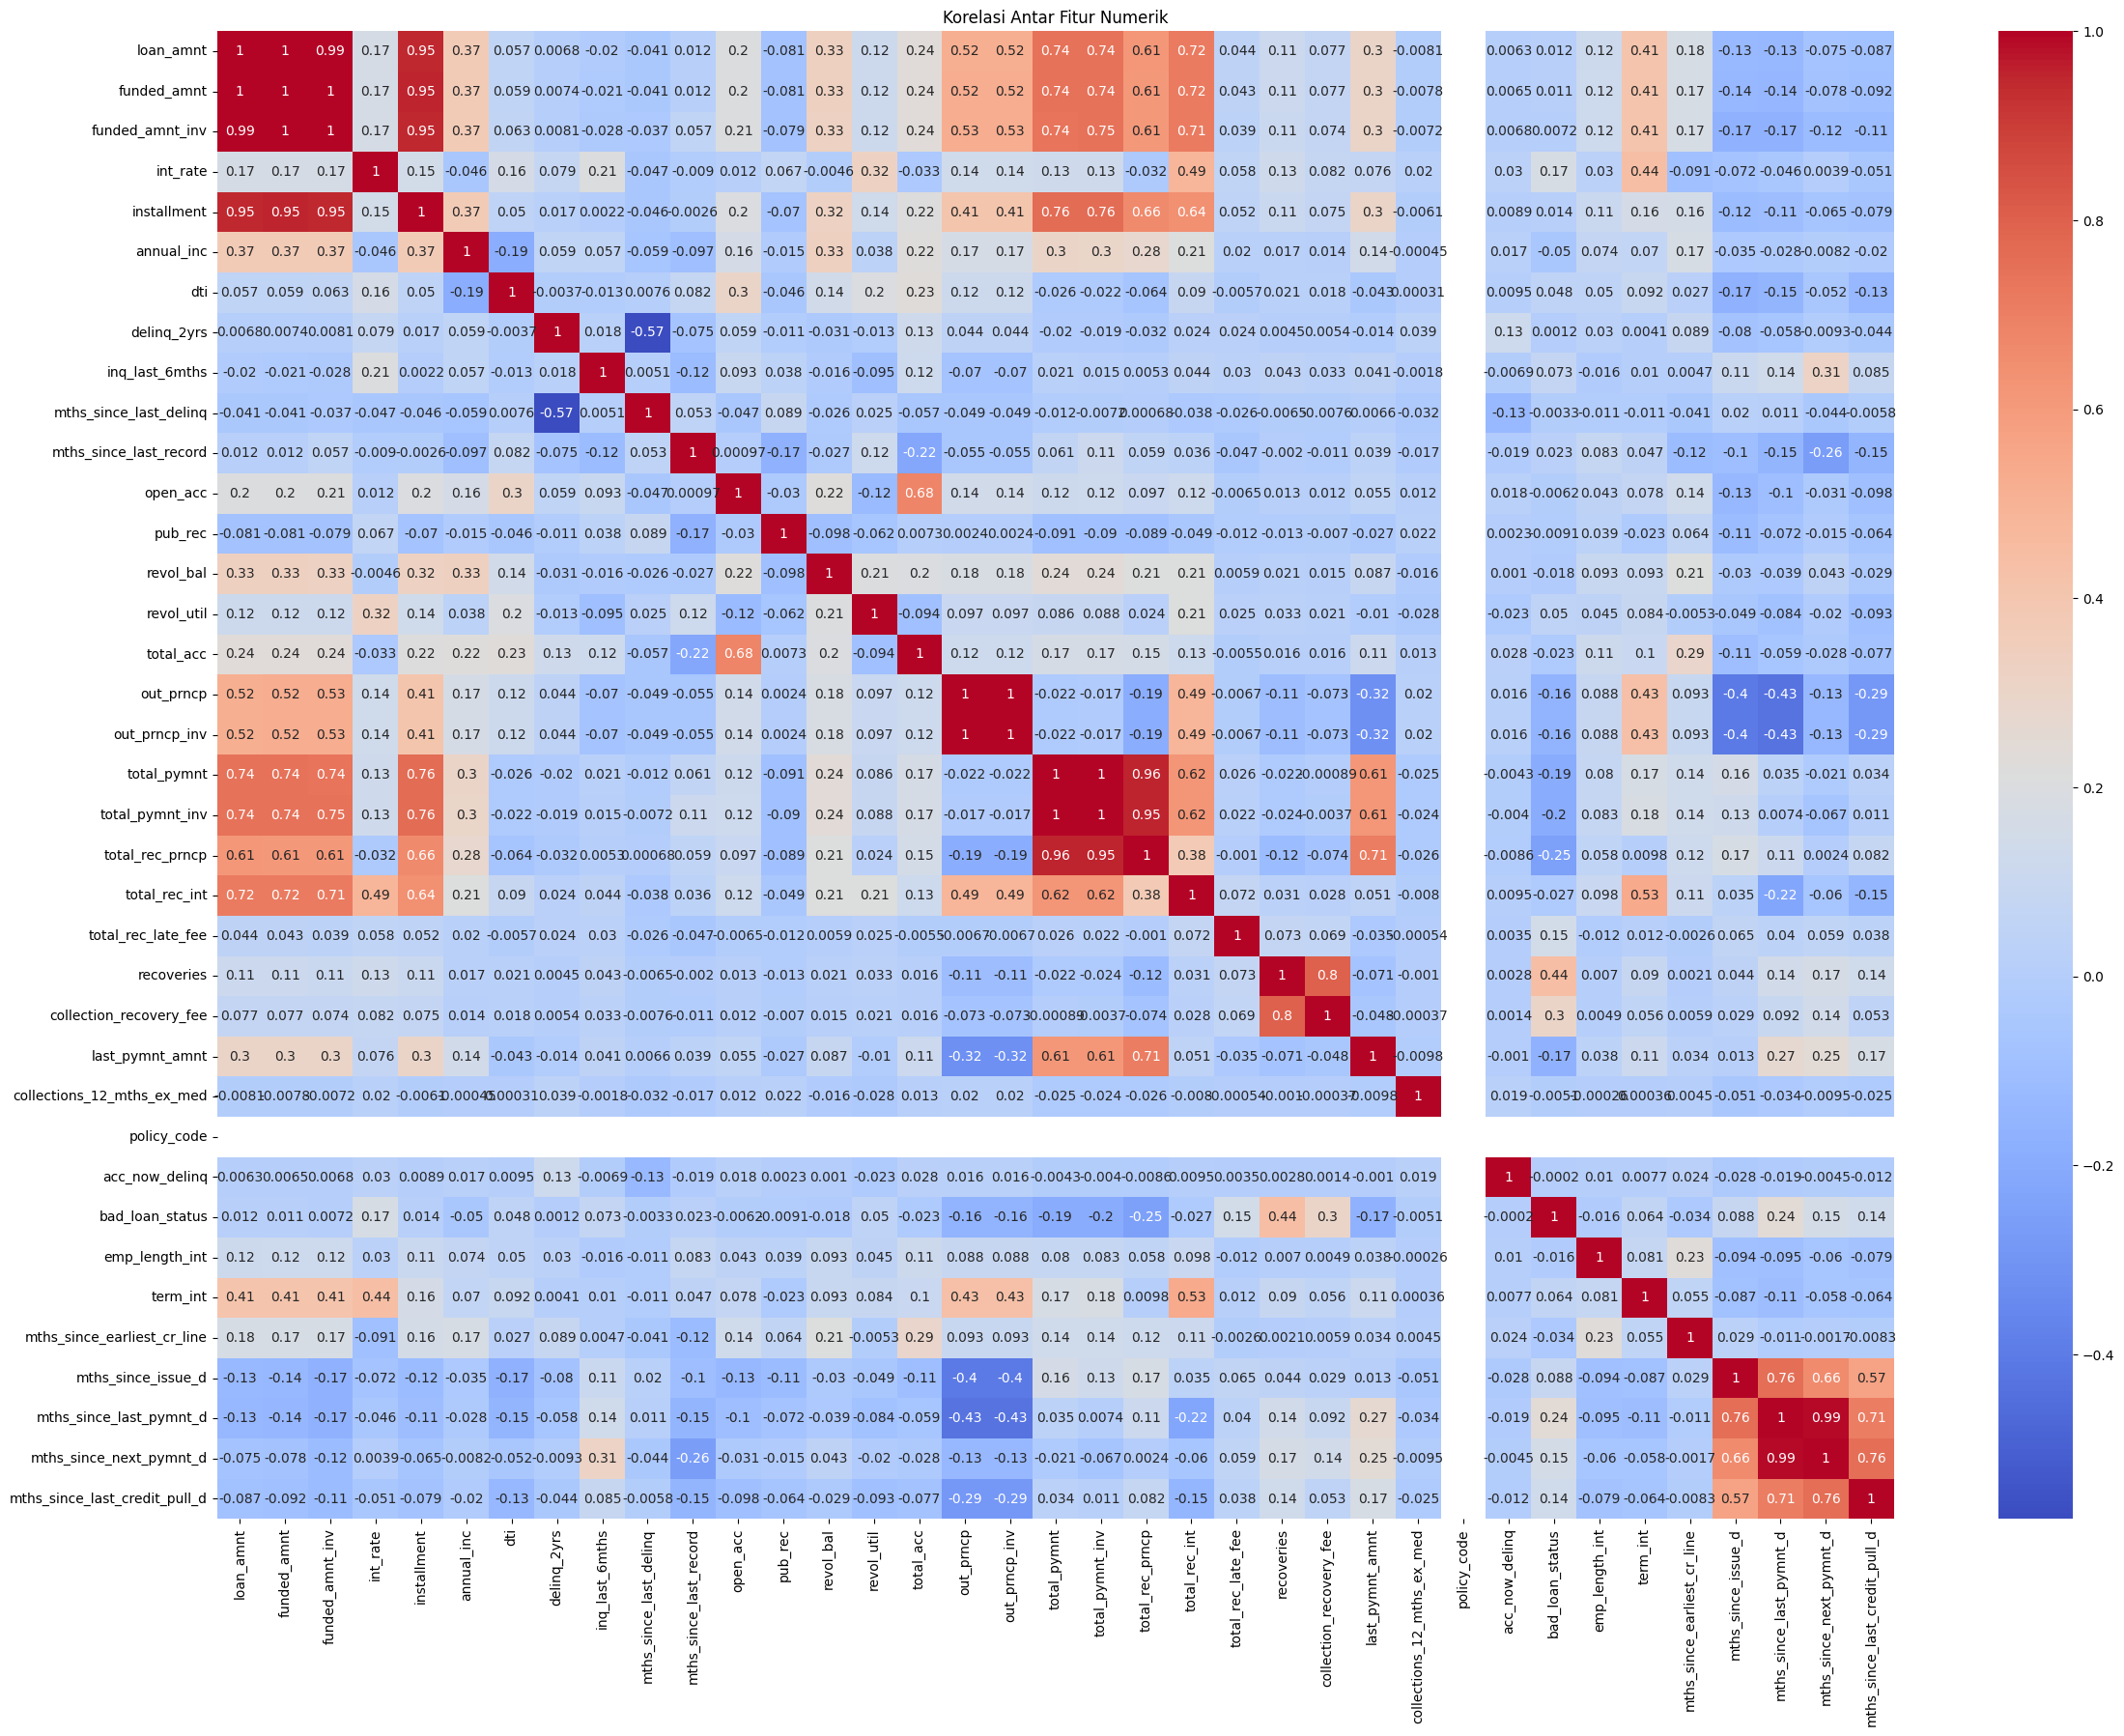

In [ ]:
#Cek Korelasi
plt.figure(figsize=(28,20))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.title("Korelasi Antar Fitur Numerik")
plt.show()

## Cek Cardinality Data

### Kategorikal Data

In [ ]:
#Menampilkan jumlah unik dari fitur-fitur dengan tipe data objek
print(df.select_dtypes(include='object').nunique())

grade                       7
emp_title              205475
home_ownership              6
verification_status         3
pymnt_plan                  2
purpose                    14
title                   63098
addr_state                 50
initial_list_status         2
application_type            1
dtype: int64


In [ ]:
#Menghapus fitur yang tidak dipakai
df.drop(['title', 'emp_title','application_type'], axis=1, inplace=True)

###Numerik Data

In [ ]:
#Menampilkan jumlah unik dari fitur-fitur dengan tipe data non-objek
print(df.select_dtypes(exclude='object').nunique())

loan_amnt                          1352
funded_amnt                        1354
funded_amnt_inv                    9854
int_rate                            506
installment                       55622
annual_inc                        31901
dti                                3997
delinq_2yrs                          24
inq_last_6mths                       28
mths_since_last_delinq              145
mths_since_last_record              123
open_acc                             62
pub_rec                              26
revol_bal                         58142
revol_util                         1269
total_acc                           112
out_prncp                        135665
out_prncp_inv                    141189
total_pymnt                      351609
total_pymnt_inv                  347659
total_rec_prncp                  172713
total_rec_int                    270249
total_rec_late_fee                 5808
recoveries                        22773
collection_recovery_fee           20275


In [ ]:
#Menghapus fitur yang tidak dipakai
df.drop(['policy_code'], axis=1, inplace=True)

### Loop

In [ ]:
#Loop Melalui setiap fitur dengan tipe data objek
for col in df.select_dtypes(include='object').columns.tolist():
    #Menampilkan Dsitribusi nilai unik dari setiap fitur
    print("Distribusi nilai unik",col)
    print(df[col].value_counts(normalize=True)*100)
    print("\n")

Distribusi nilai unik grade
grade
B    29.365946
C    26.870476
D    16.489486
A    16.056060
E     7.668486
F     2.837106
G     0.712440
Name: proportion, dtype: float64


Distribusi nilai unik home_ownership
home_ownership
MORTGAGE    50.586015
RENT        40.420129
OWN          8.943886
OTHER        0.039032
NONE         0.010723
ANY          0.000214
Name: proportion, dtype: float64


Distribusi nilai unik verification_status
verification_status
Verified           36.041262
Source Verified    32.167666
Not Verified       31.791072
Name: proportion, dtype: float64


Distribusi nilai unik pymnt_plan
pymnt_plan
n    99.99807
y     0.00193
Name: proportion, dtype: float64


Distribusi nilai unik purpose
purpose
debt_consolidation    58.804165
credit_card           22.337626
home_improvement       5.691155
other                  5.080584
major_purchase         2.107724
small_business         1.504016
car                    1.157447
medical                0.986950
moving                

In [ ]:
#Menghapus fitur 'pymnt_plan'
df.drop('pymnt_plan', axis=1, inplace=True)

## Univariate Analysis

### Kategorikal Data

In [ ]:
#Identifikasi variabel kategorikal
categorical_var = df.select_dtypes(include=['object']).columns
print(categorical_var)

Index(['grade', 'home_ownership', 'verification_status', 'purpose',
       'addr_state', 'initial_list_status'],
      dtype='object')


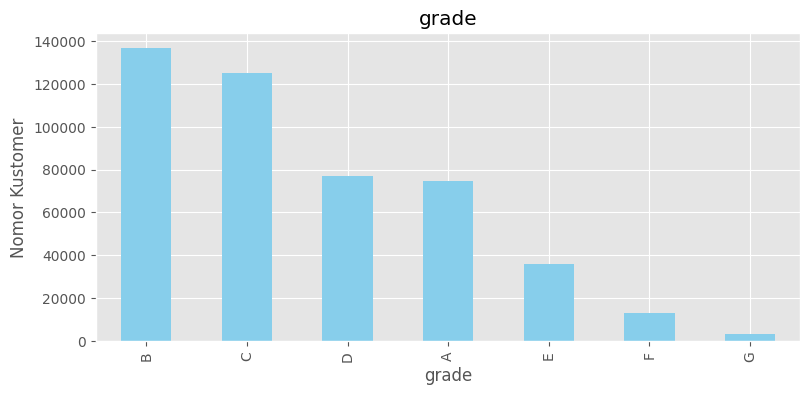

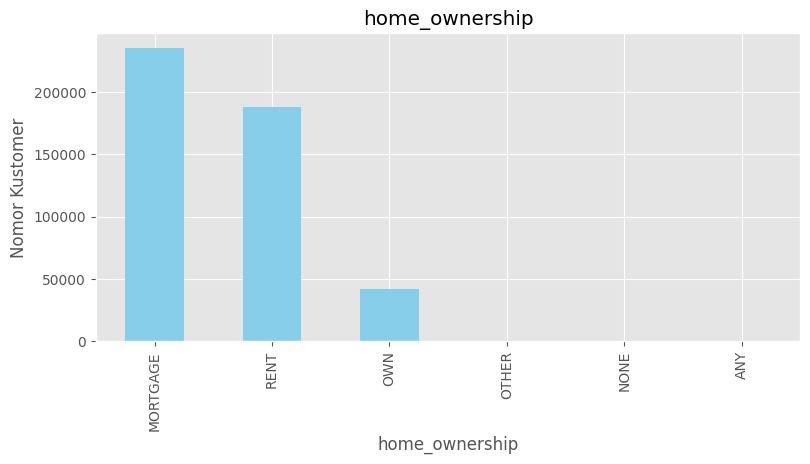

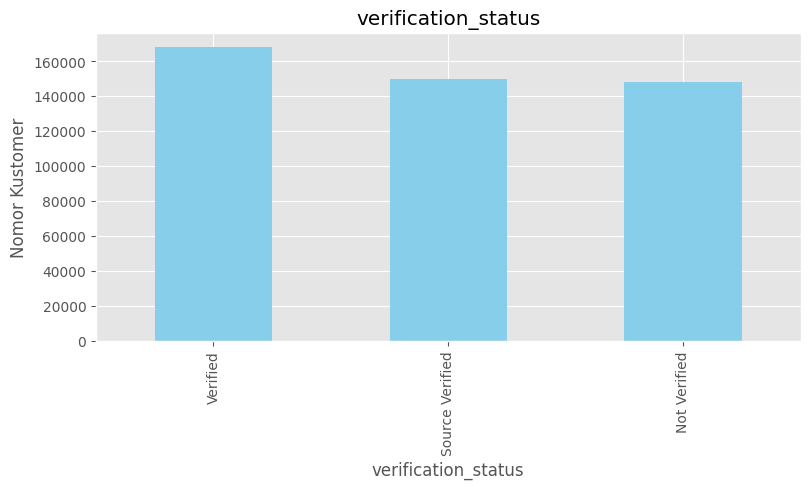

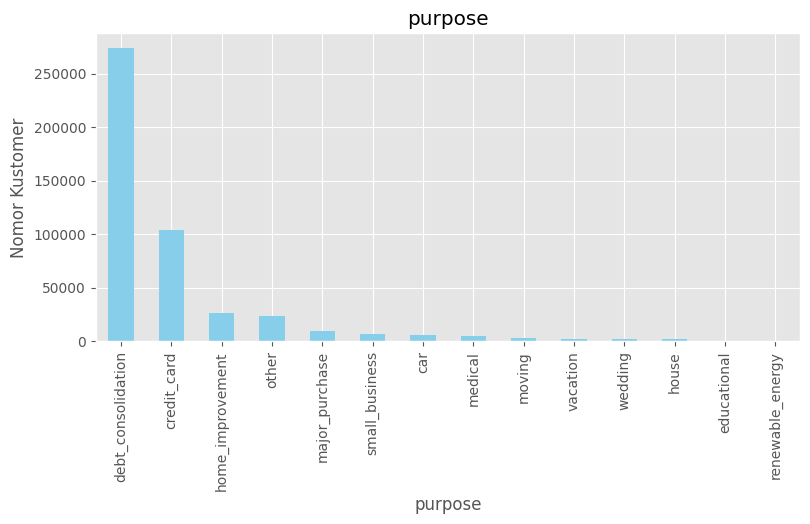

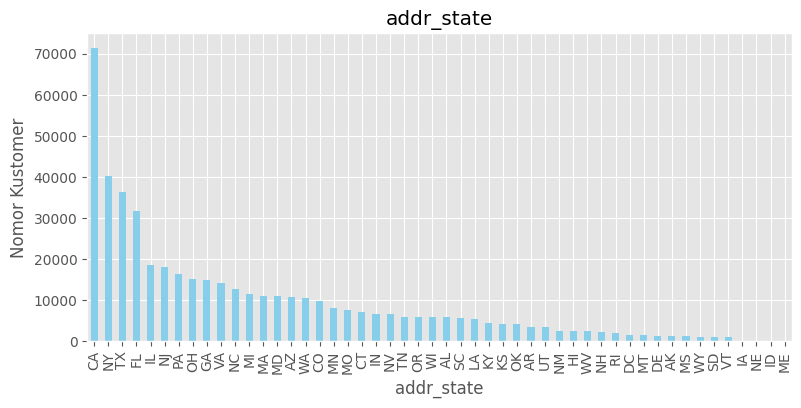

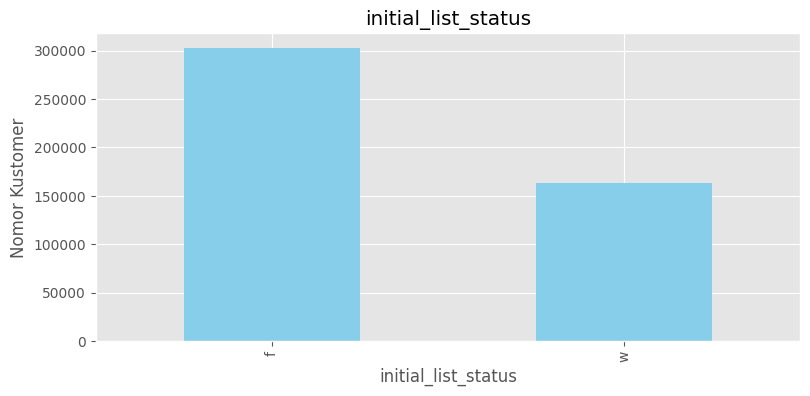

In [ ]:
#Plotting bar chart untuk setiap variabel
plt.style.use('ggplot')

for column in categorical_var:
  plt.figure(figsize=(20,4))
  plt.subplot(1,2,1)
  df[column].value_counts().plot(kind='bar', color=['skyblue'])
  plt.xlabel(column)
  plt.ylabel('Nomor Kustomer')
  plt.title(column)

###Numerik Data

In [ ]:
#Identifikasi Variabel Numerik
numerical_var = df.select_dtypes(include=np.number)
numerical_var

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,...,collections_12_mths_ex_med,acc_now_delinq,bad_loan_status,emp_length_int,term_int,mths_since_earliest_cr_line,mths_since_issue_d,mths_since_last_pymnt_d,mths_since_next_pymnt_d,mths_since_last_credit_pull_d
0,5000,5000,4975.0,10.65,162.87,24000.0,27.65,0.0,1.0,NaN,...,0.0,0.0,0,10.0,36.0,395.0,72,35.0,NaN,23.0
1,2500,2500,2500.0,15.27,59.83,30000.0,1.00,0.0,5.0,NaN,...,0.0,0.0,1,1.0,60.0,224.0,72,56.0,NaN,51.0
2,2400,2400,2400.0,15.96,84.33,12252.0,8.72,0.0,2.0,NaN,...,0.0,0.0,0,10.0,36.0,193.0,72,42.0,NaN,23.0
3,10000,10000,10000.0,13.49,339.31,49200.0,20.00,0.0,1.0,35.0,...,0.0,0.0,0,10.0,36.0,262.0,72,35.0,NaN,35.0
4,3000,3000,3000.0,12.69,67.79,80000.0,17.94,0.0,0.0,38.0,...,0.0,0.0,0,1.0,60.0,263.0,72,23.0,22.0,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,18400,18400,18400.0,14.47,432.64,110000.0,19.85,0.0,2.0,NaN,...,0.0,0.0,0,4.0,60.0,176.0,47,23.0,22.0,23.0
466281,22000,22000,22000.0,19.97,582.50,78000.0,18.45,0.0,5.0,NaN,...,0.0,0.0,1,10.0,60.0,246.0,47,36.0,NaN,23.0
466282,20700,20700,20700.0,16.99,514.34,46000.0,25.65,0.0,2.0,65.0,...,0.0,0.0,0,7.0,60.0,192.0,47,23.0,22.0,24.0
466283,2000,2000,2000.0,7.90,62.59,83000.0,5.39,3.0,1.0,13.0,...,0.0,0.0,0,3.0,36.0,178.0,47,36.0,NaN,32.0


Ringkasan Statistik untuk loan_amnt
Mean: 14317.28
Median: 12000.00
Mode: 10000.00
Standar Deviasi: 8286.51
Ringkasan Statistik untuk funded_amnt
Mean: 14291.80
Median: 12000.00
Mode: 10000.00
Standar Deviasi: 8274.37
Ringkasan Statistik untuk funded_amnt_inv
Mean: 14222.33
Median: 12000.00
Mode: 10000.00
Standar Deviasi: 8297.64
Ringkasan Statistik untuk int_rate
Mean: 13.83
Median: 13.66
Mode: 12.99
Standar Deviasi: 4.36
Ringkasan Statistik untuk installment
Mean: 432.06
Median: 379.89
Mode: 327.34
Standar Deviasi: 243.49
Ringkasan Statistik untuk annual_inc
Mean: 73277.38
Median: 63000.00
Mode: 60000.00
Standar Deviasi: 54963.57
Ringkasan Statistik untuk dti
Mean: 17.22
Median: 16.87
Mode: 14.40
Standar Deviasi: 7.85
Ringkasan Statistik untuk delinq_2yrs
Mean: 0.28
Median: 0.00
Mode: 0.00
Standar Deviasi: 0.80
Ringkasan Statistik untuk inq_last_6mths
Mean: 0.80
Median: 0.00
Mode: 0.00
Standar Deviasi: 1.09
Ringkasan Statistik untuk mths_since_last_delinq
Mean: 34.10
Median: 31.00
Mo

/tmp/ipython-input-2807914460.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(20,4))


Ringkasan Statistik untuk mths_since_last_record
Mean: 74.31
Median: 76.00
Mode: 0.00
Standar Deviasi: 30.36
Ringkasan Statistik untuk open_acc
Mean: 11.19
Median: 10.00
Mode: 9.00
Standar Deviasi: 4.99
Ringkasan Statistik untuk pub_rec
Mean: 0.16
Median: 0.00
Mode: 0.00
Standar Deviasi: 0.51
Ringkasan Statistik untuk revol_bal
Mean: 16230.20
Median: 11764.00
Mode: 0.00
Standar Deviasi: 20676.25
Ringkasan Statistik untuk revol_util
Mean: 56.18
Median: 57.60
Mode: 0.00
Standar Deviasi: 23.73
Ringkasan Statistik untuk total_acc
Mean: 25.06
Median: 23.00
Mode: 21.00
Standar Deviasi: 11.60
Ringkasan Statistik untuk out_prncp
Mean: 4410.06
Median: 441.47
Mode: 0.00
Standar Deviasi: 6355.08
Ringkasan Statistik untuk out_prncp_inv
Mean: 4408.45
Median: 441.38
Mode: 0.00
Standar Deviasi: 6353.20
Ringkasan Statistik untuk total_pymnt
Mean: 11540.69
Median: 9419.25
Mode: 6743.73
Standar Deviasi: 8265.63
Ringkasan Statistik untuk total_pymnt_inv
Mean: 11469.89
Median: 9355.43
Mode: 0.00
Standar D

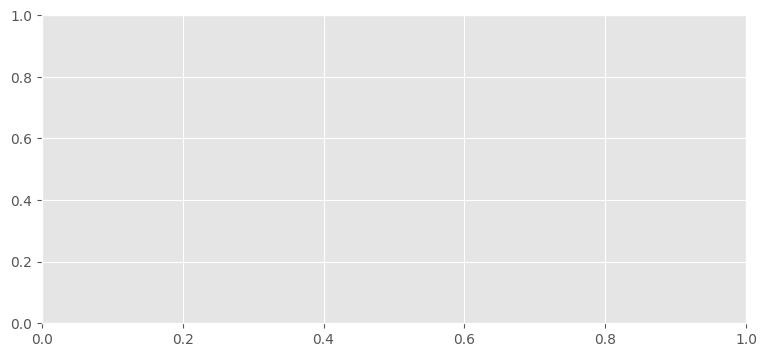

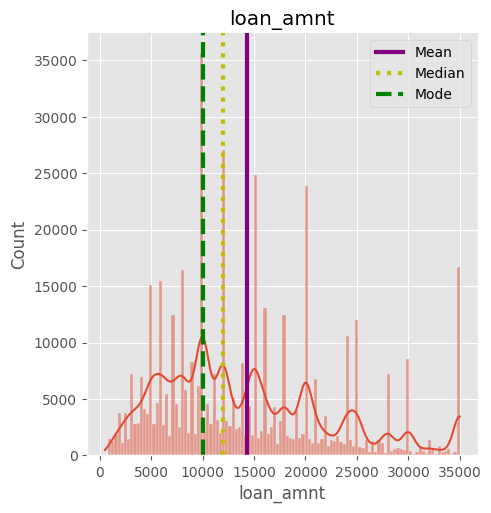

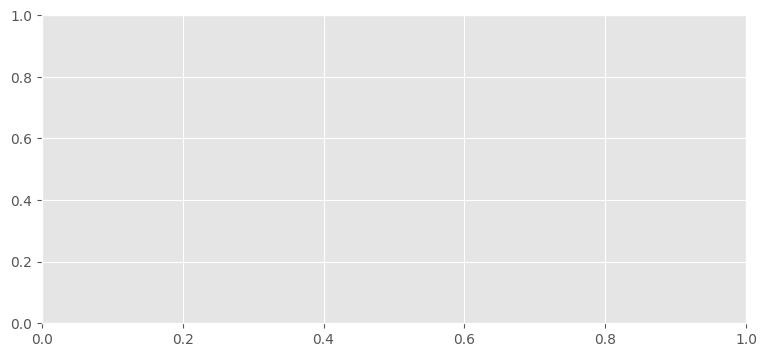

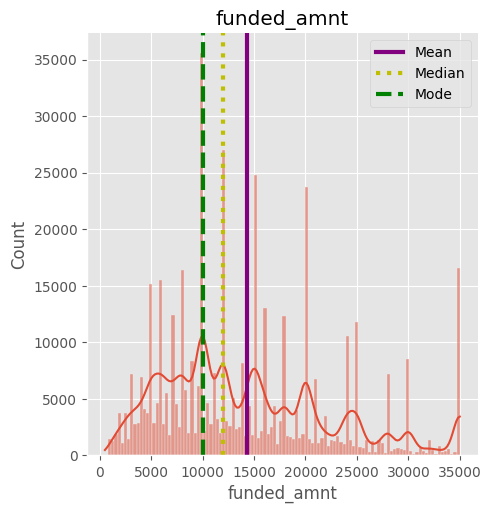

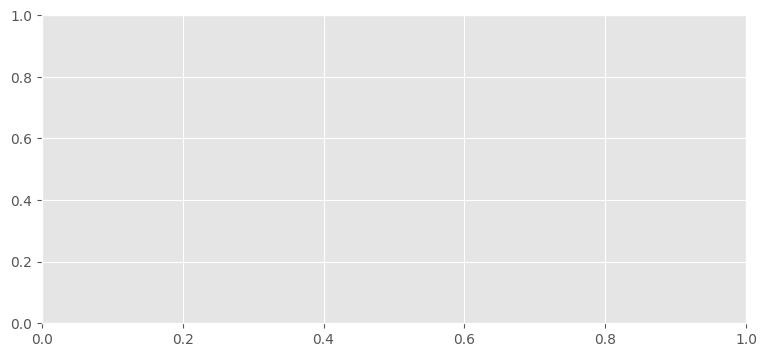

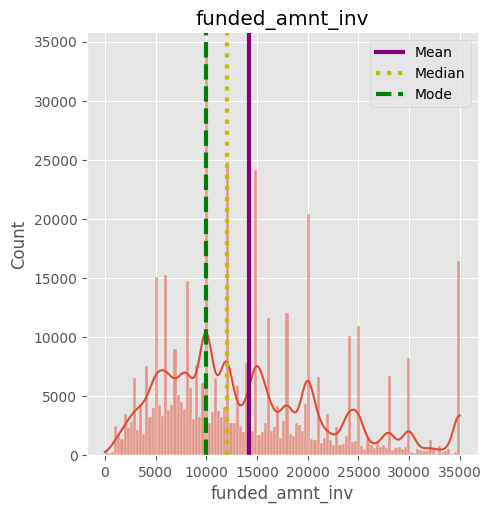

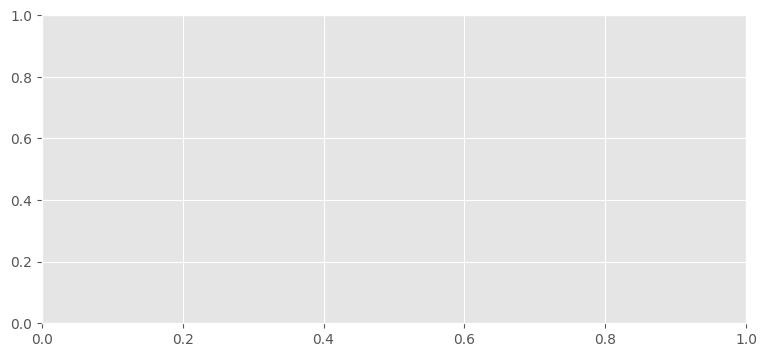

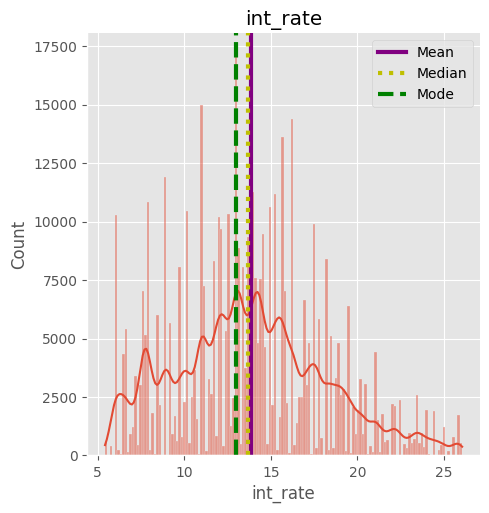

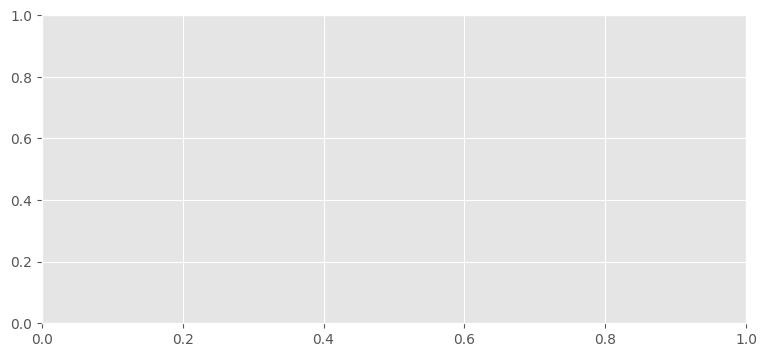

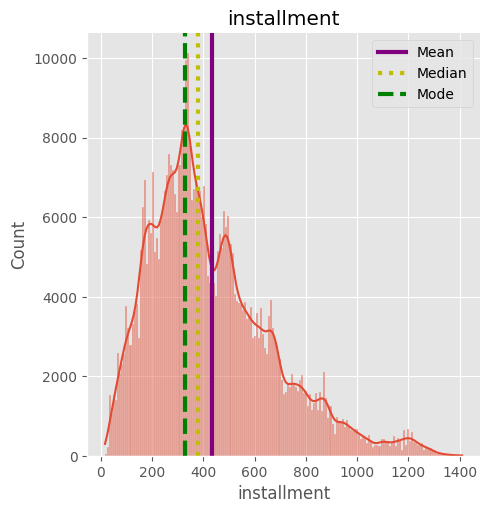

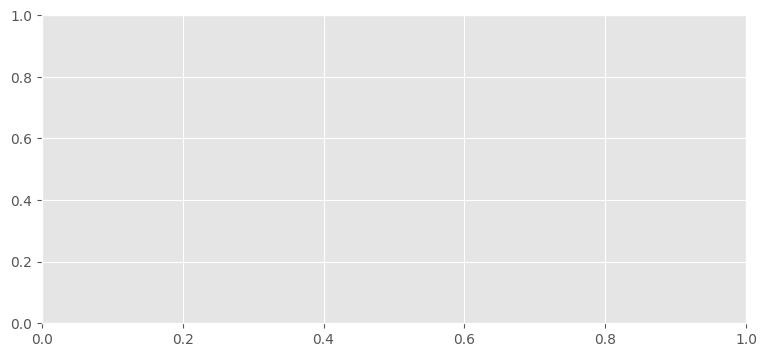

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


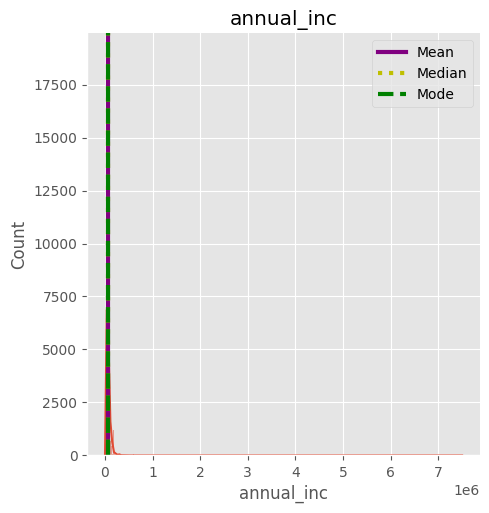

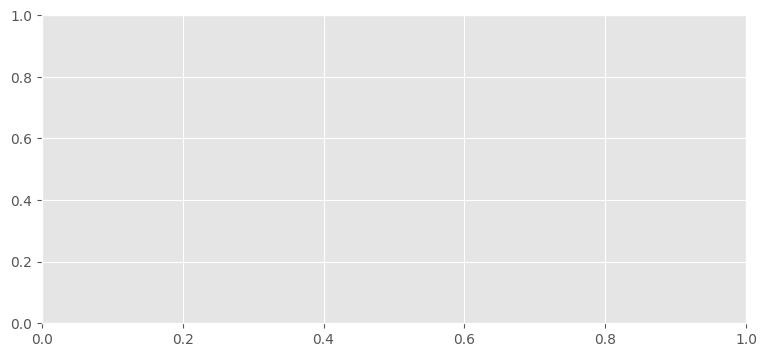

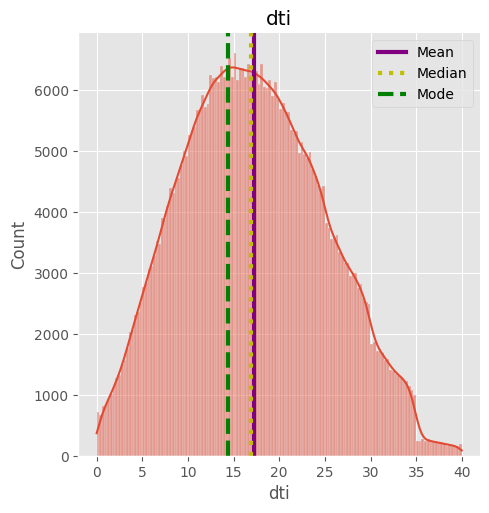

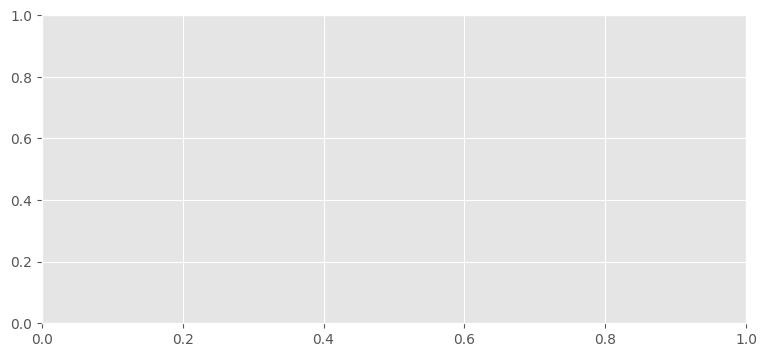

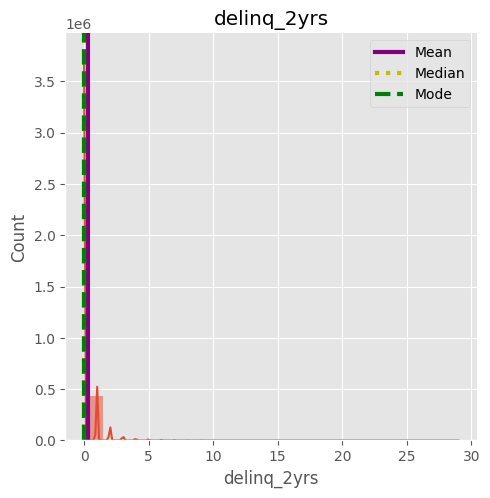

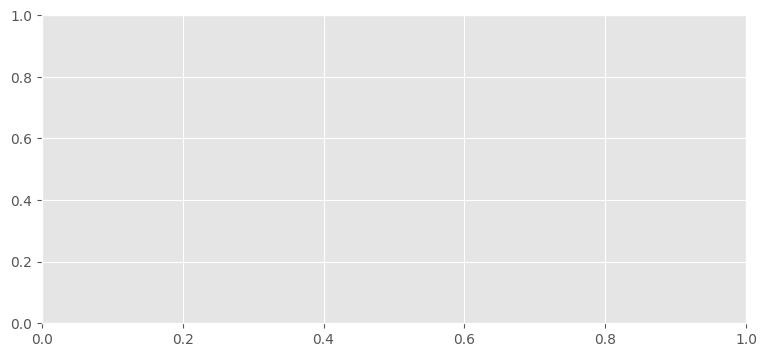

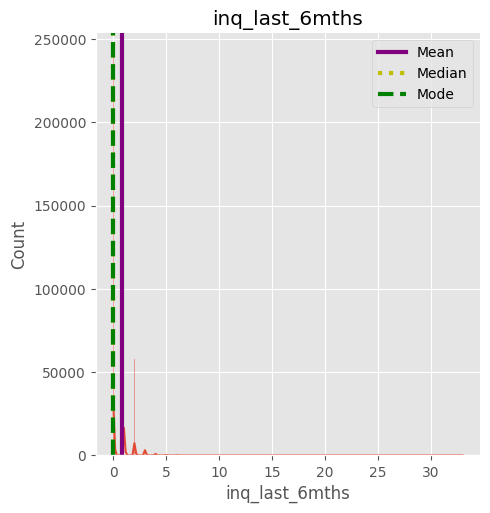

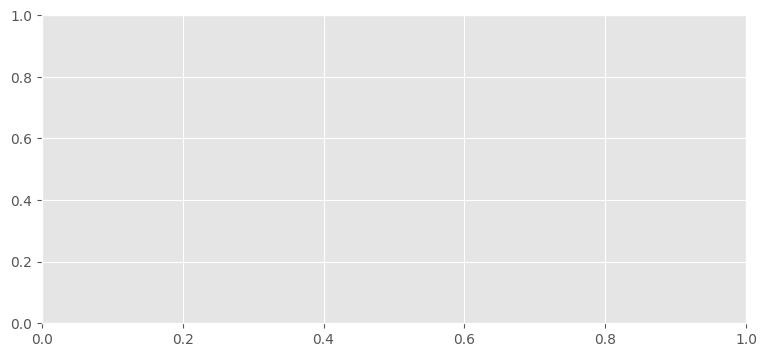

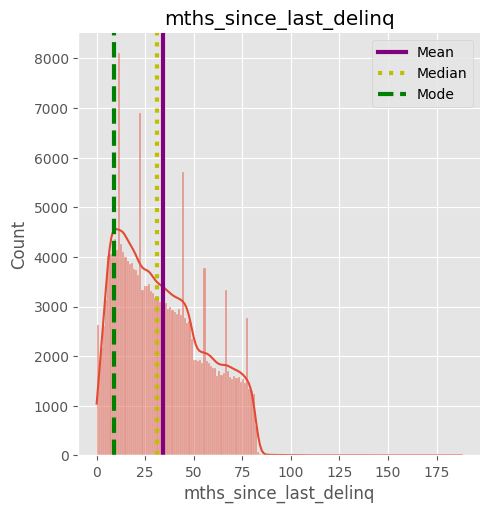

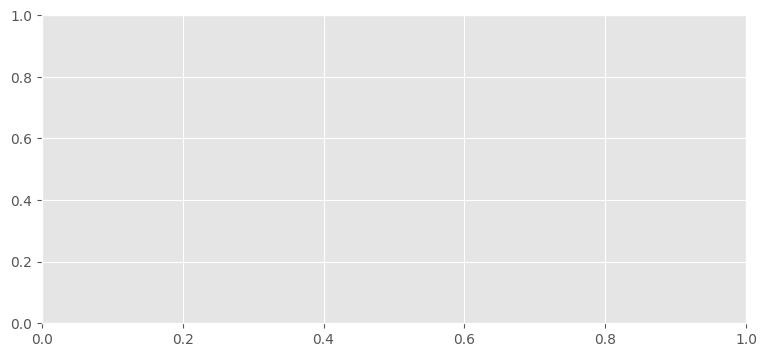

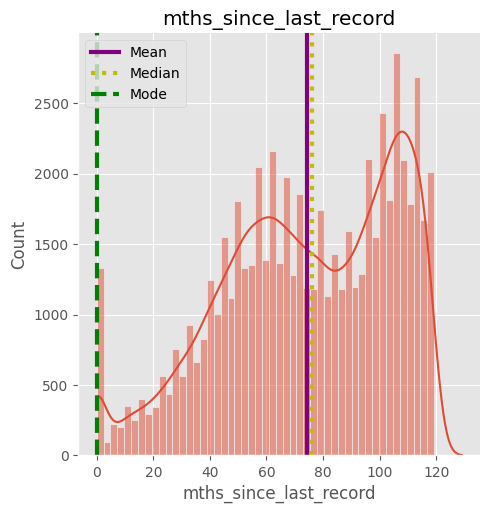

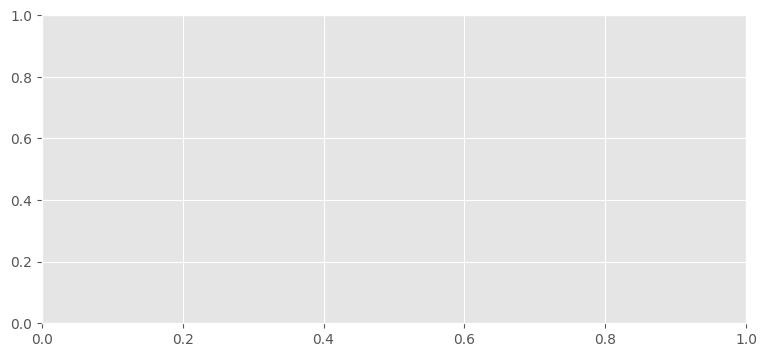

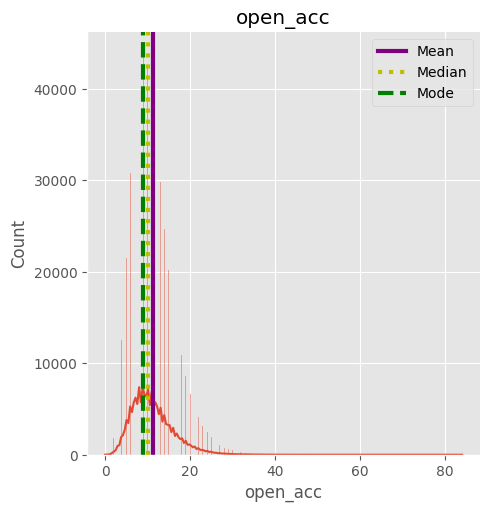

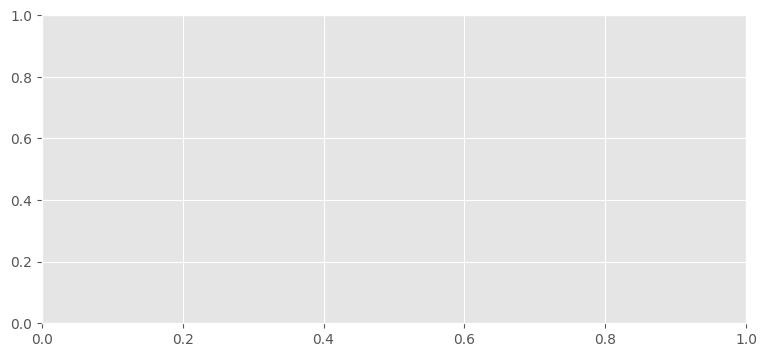

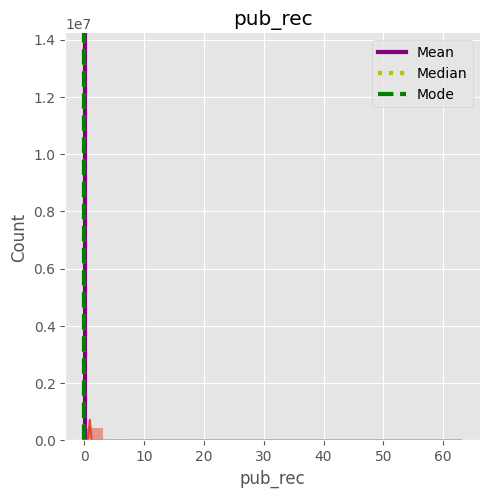

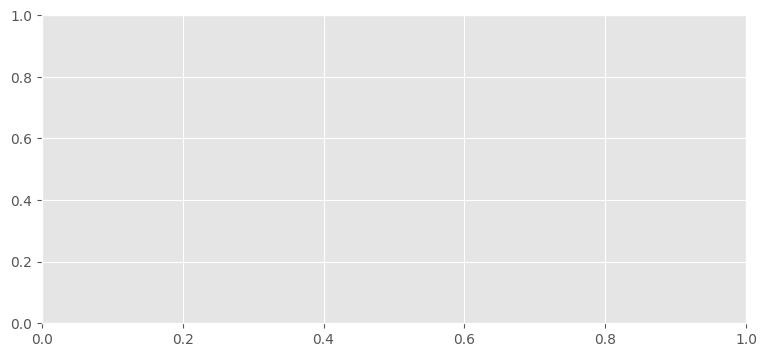

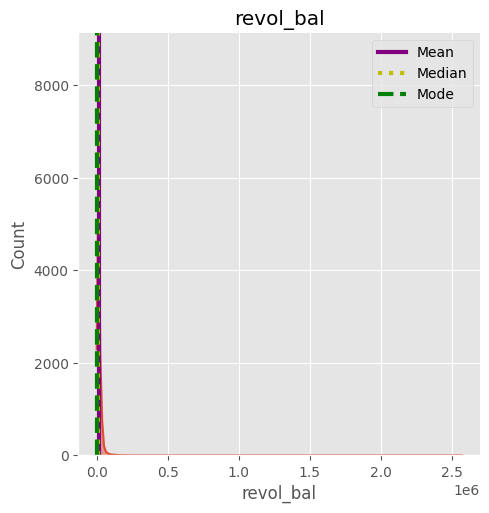

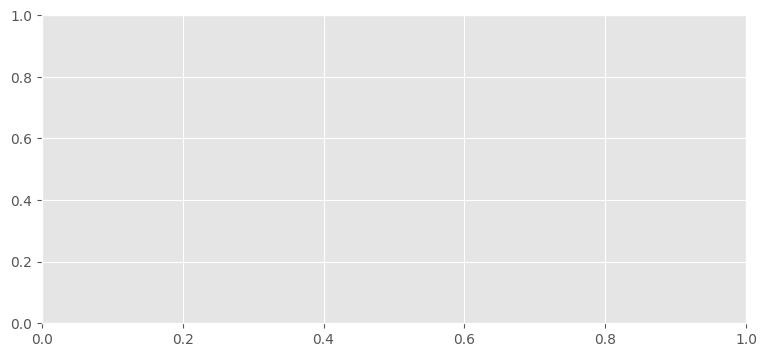

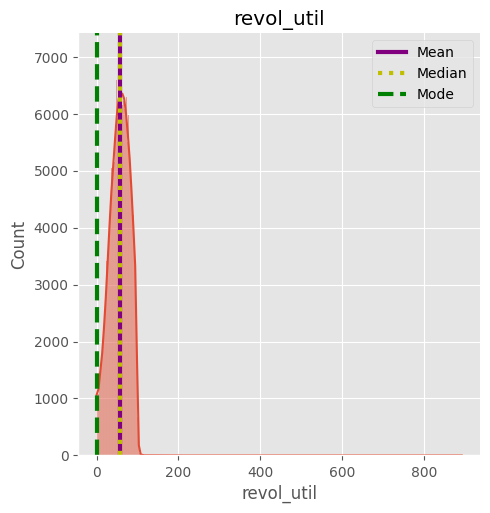

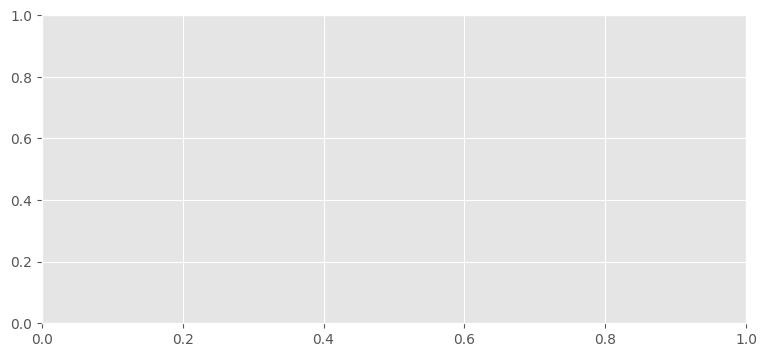

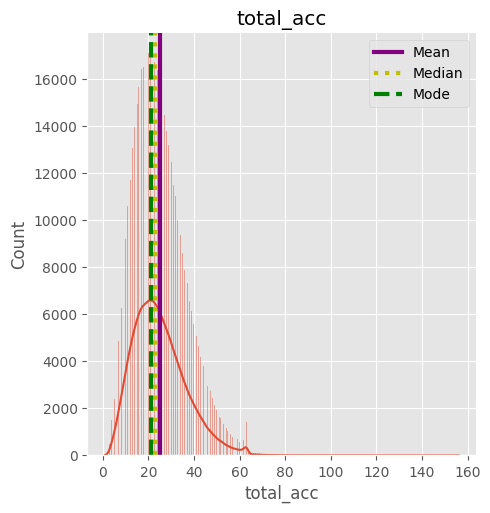

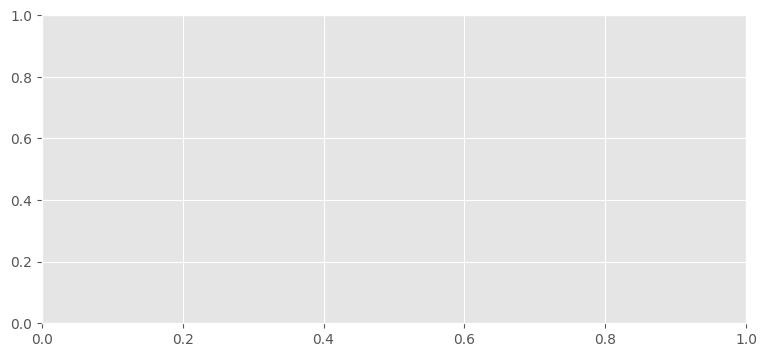

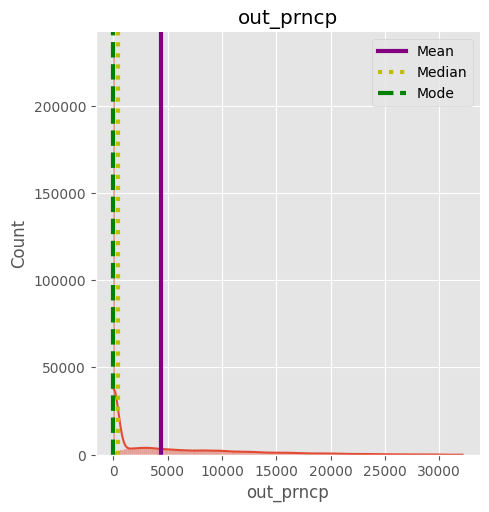

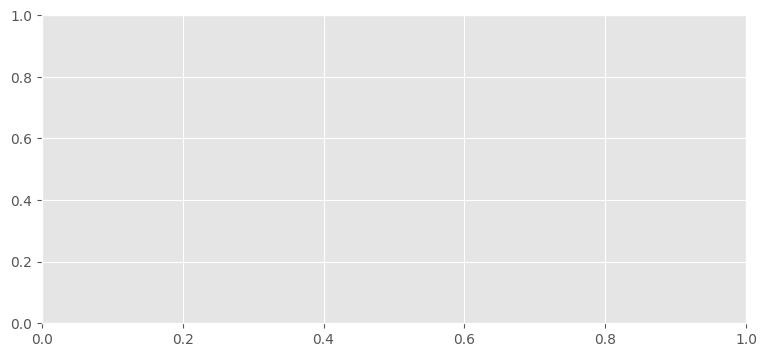

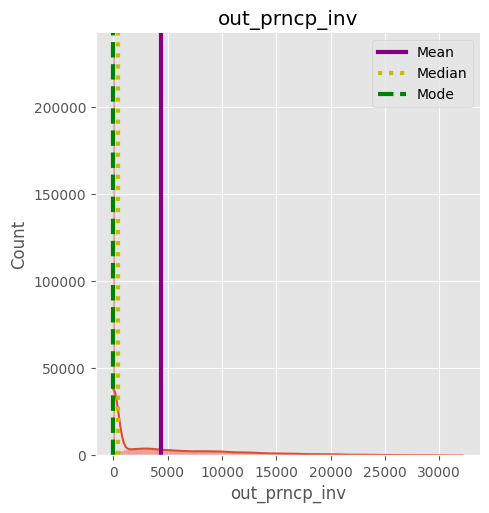

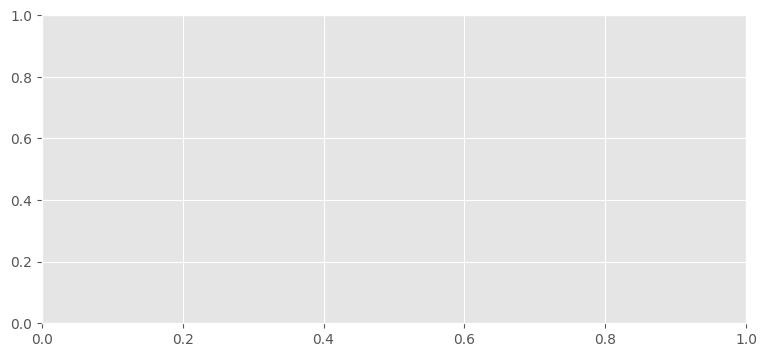

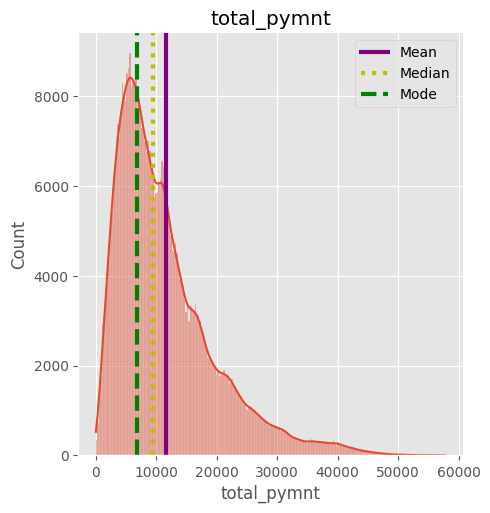

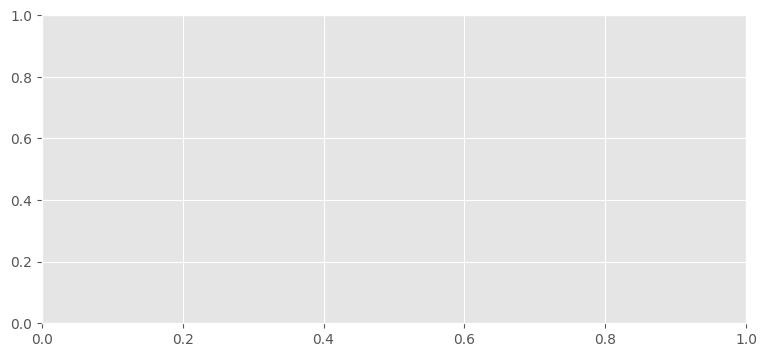

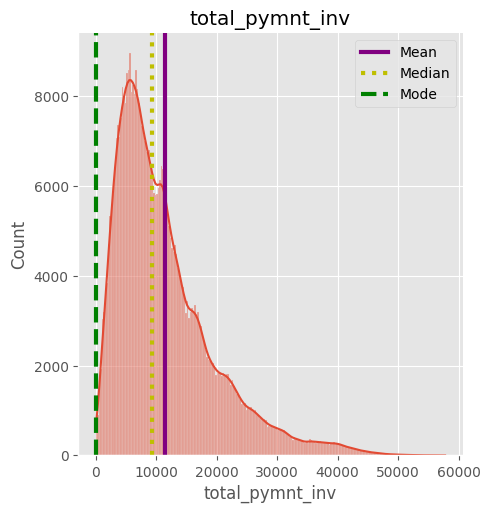

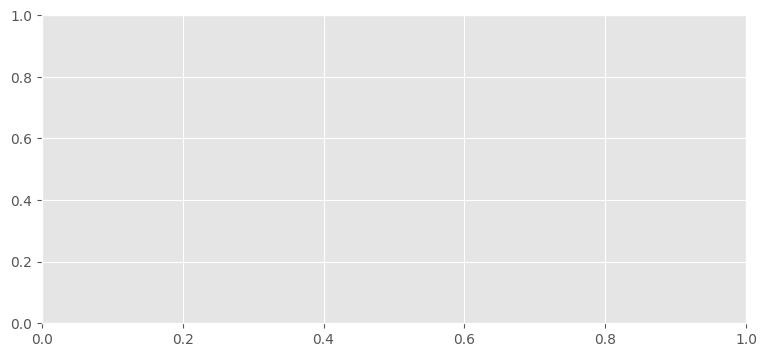

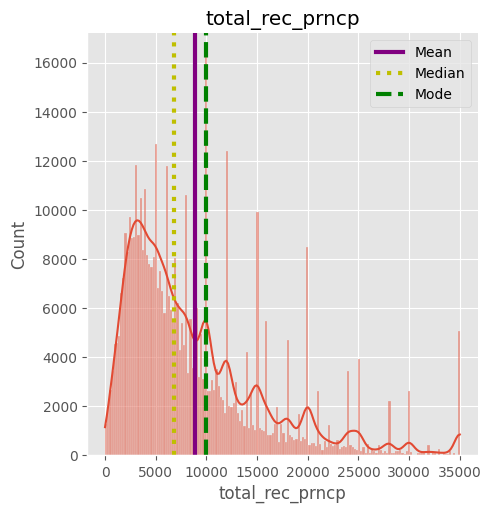

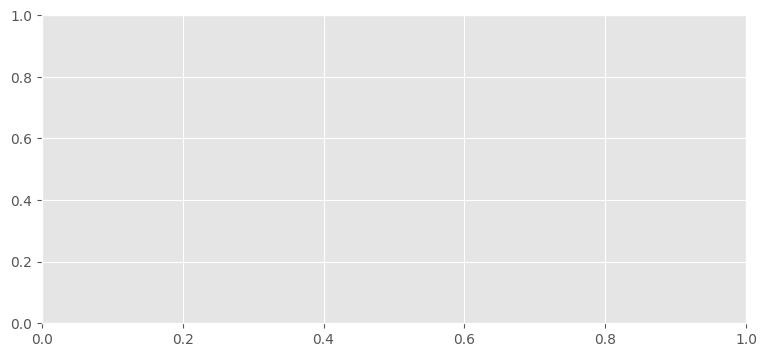

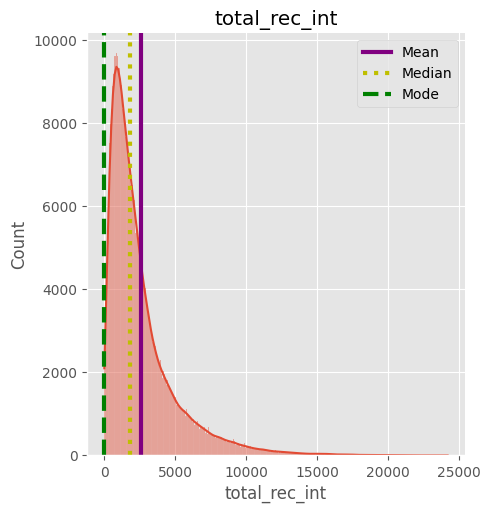

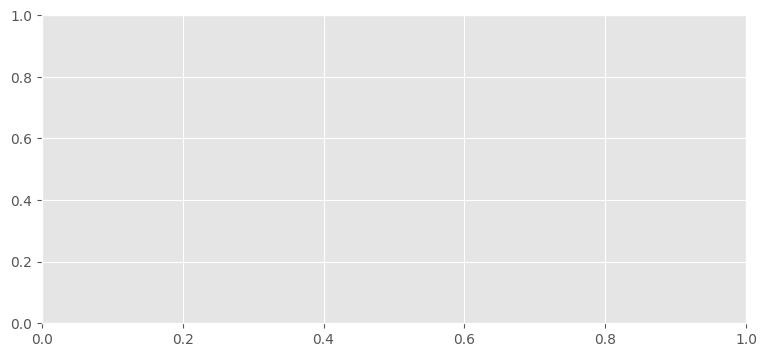

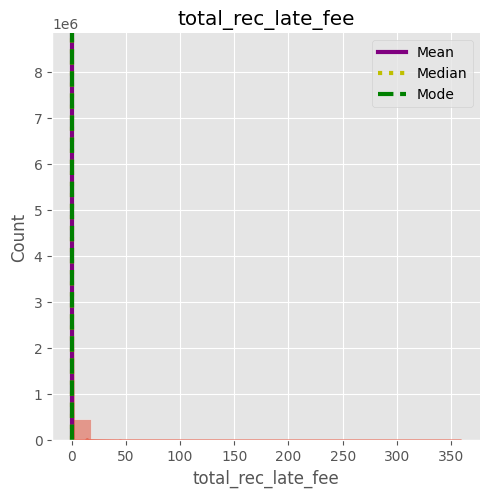

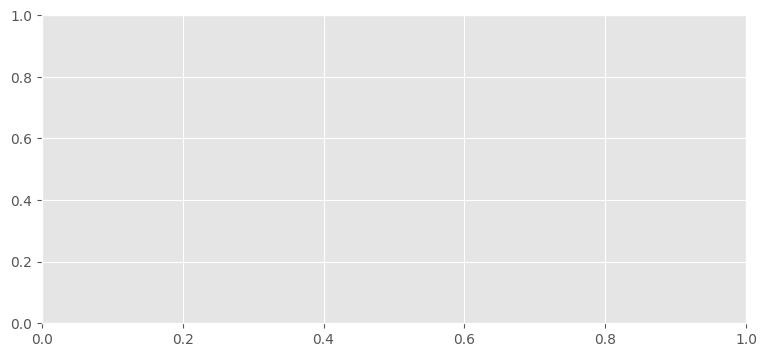

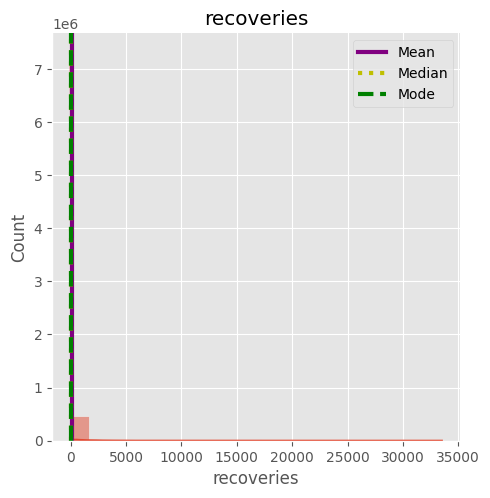

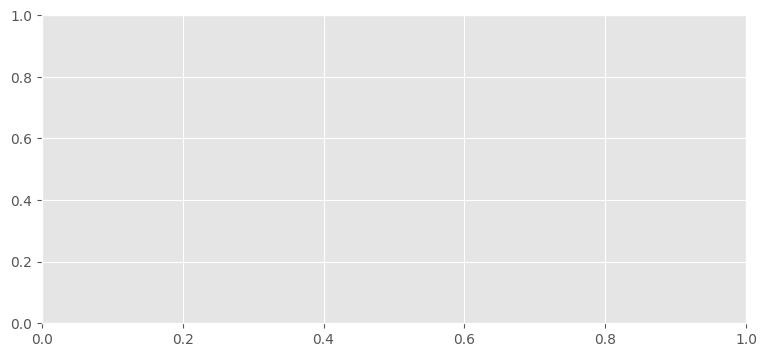

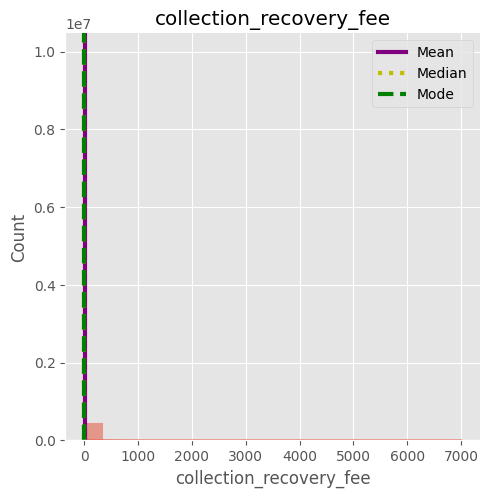

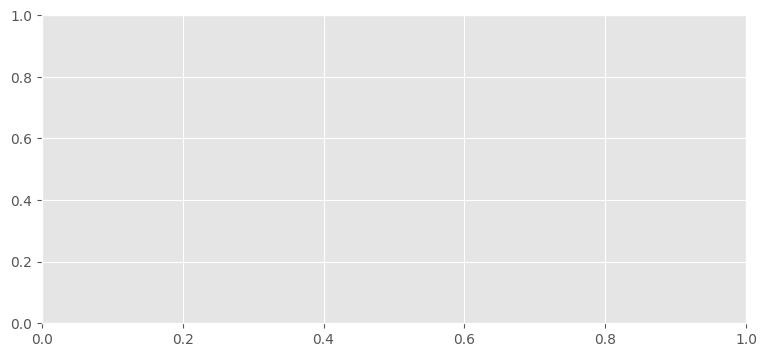

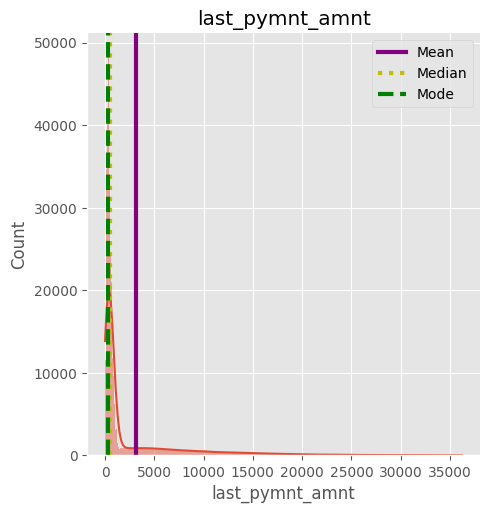

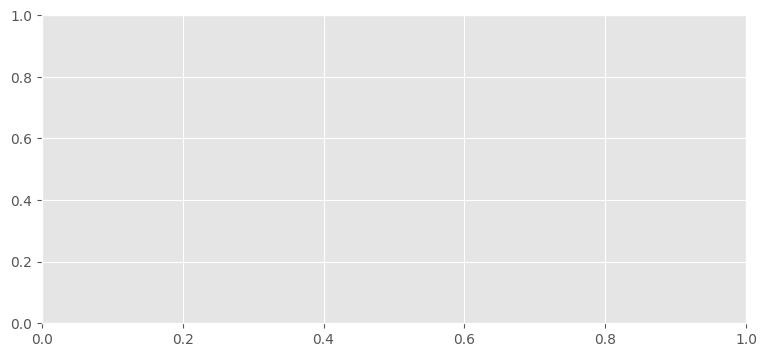

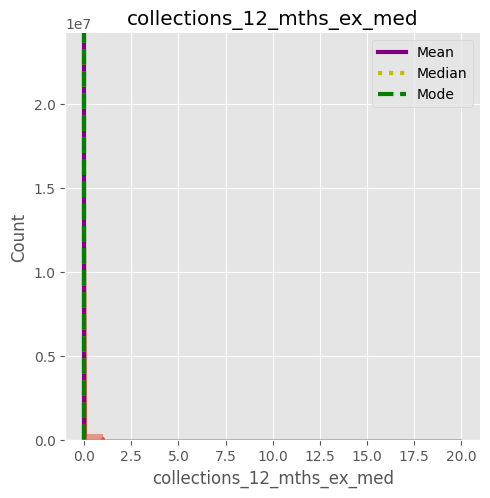

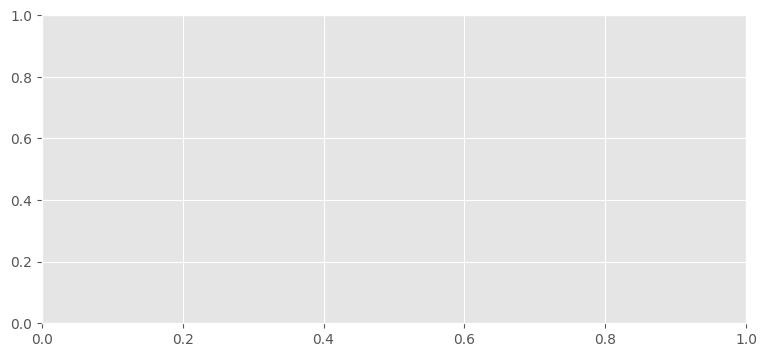

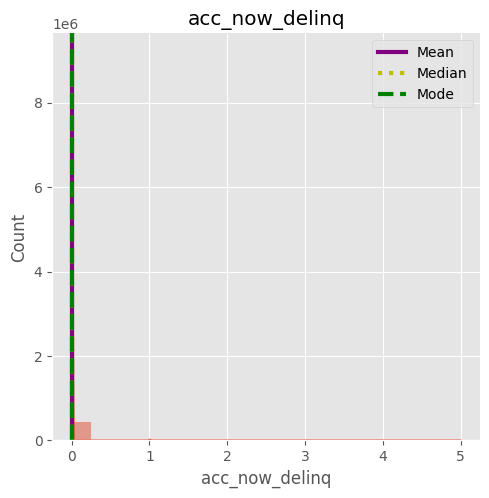

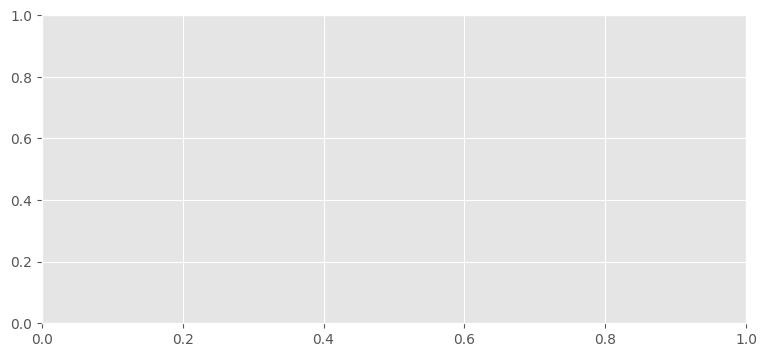

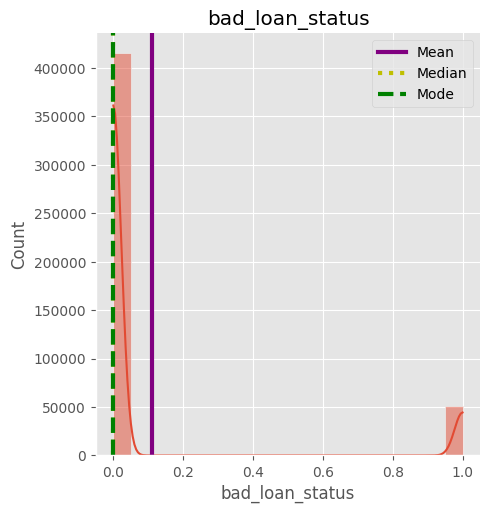

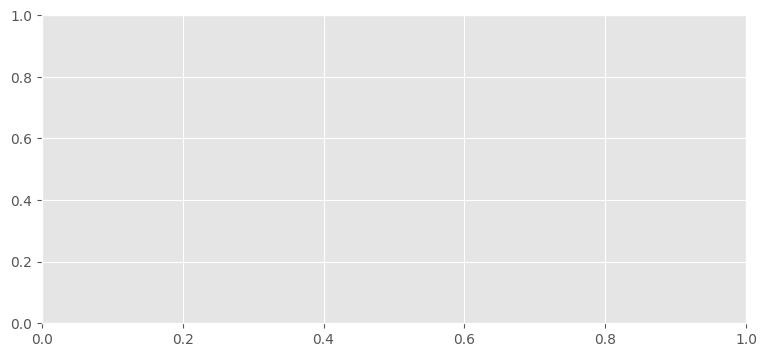

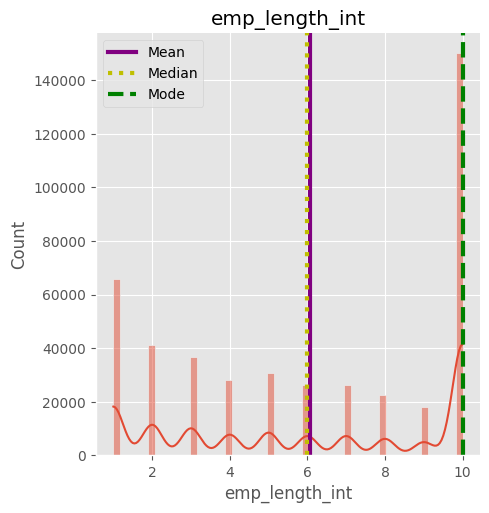

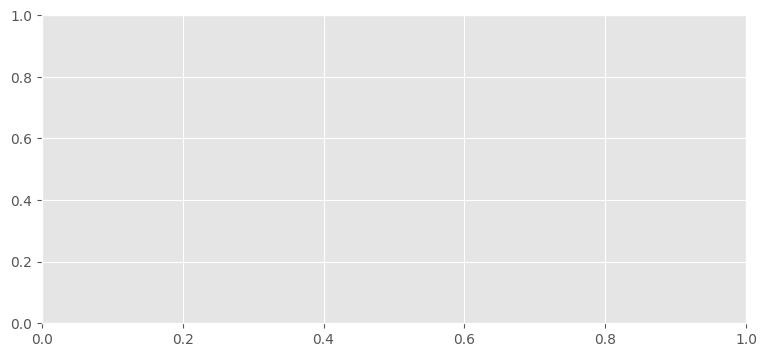

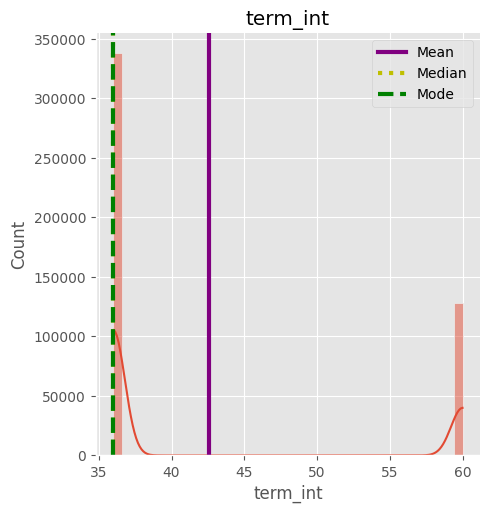

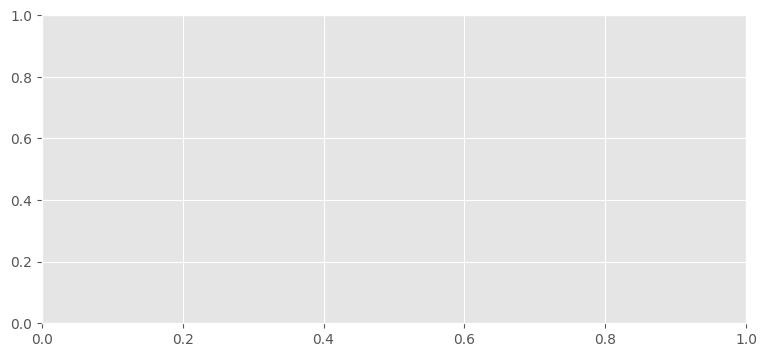

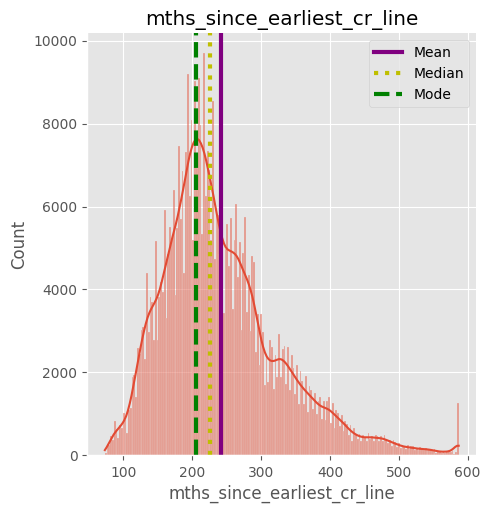

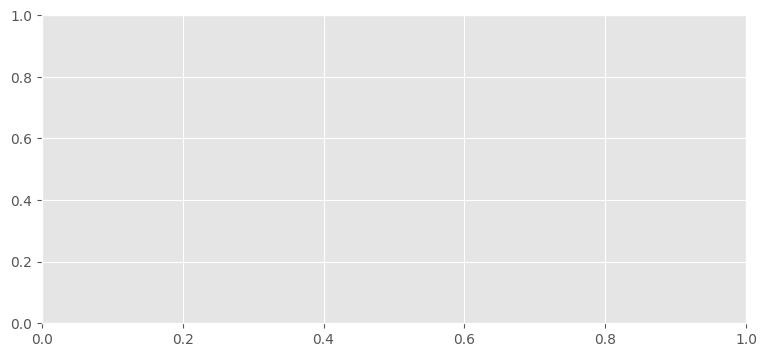

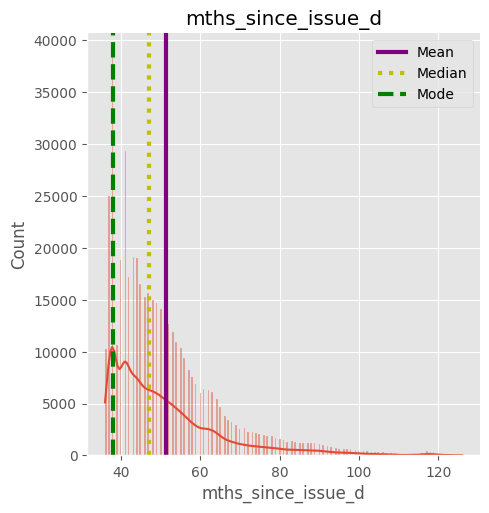

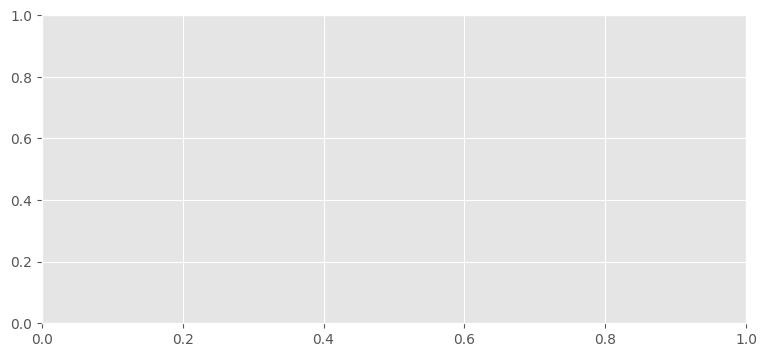

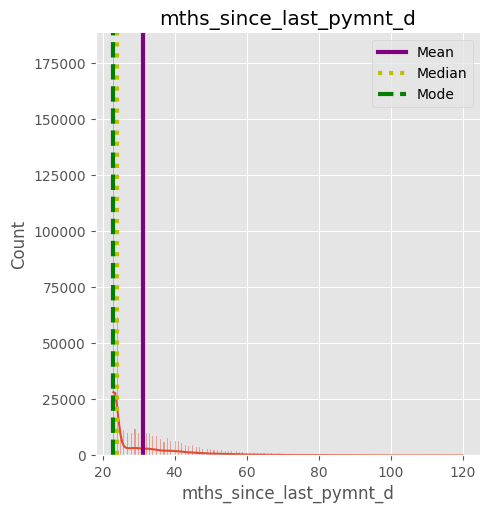

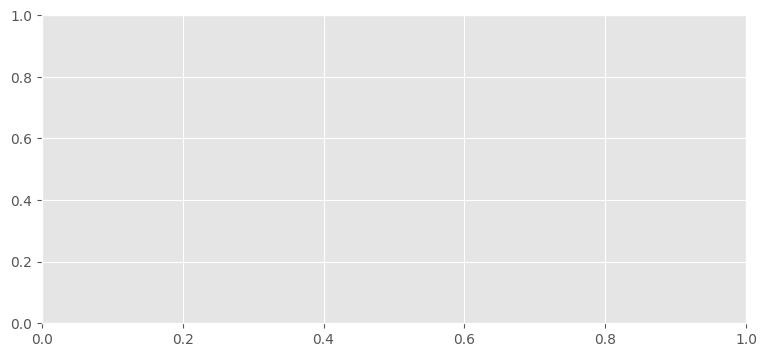

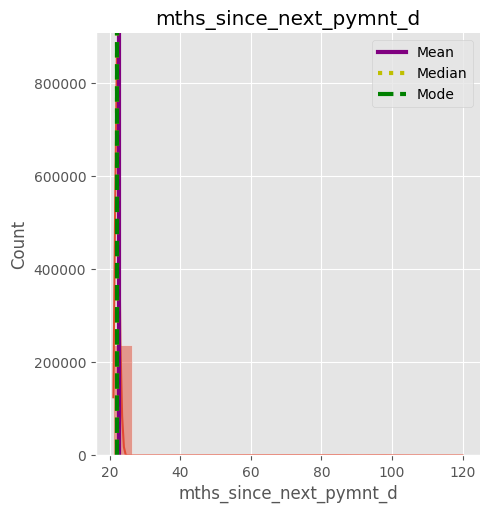

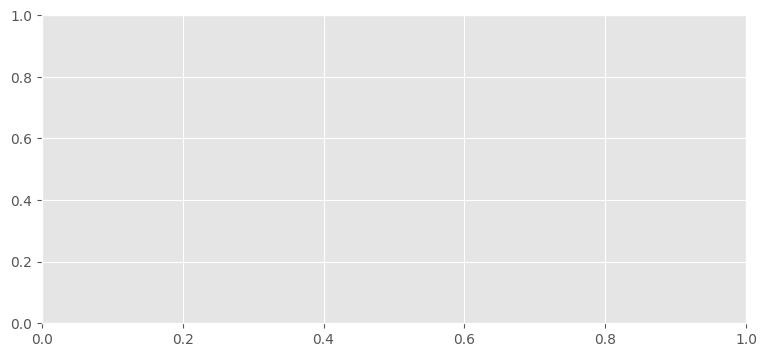

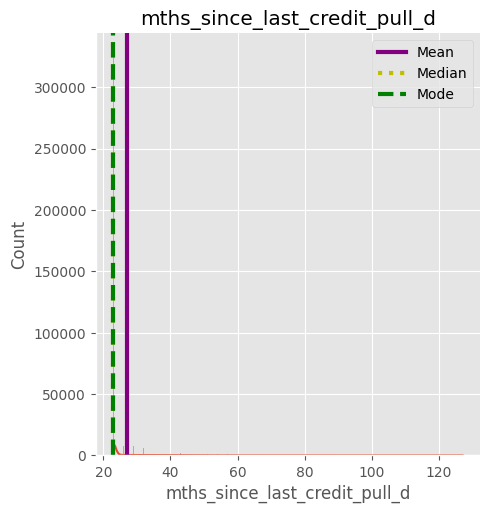

In [ ]:
#Plot Histogram untuk setiap variabel numerik
plt.style.use('ggplot')
for column in numerical_var:
  #Menghitung Statistik Deskriptif
  average = df[column].mean()
  median = df[column].median()
  mode = df[column].mode().iloc[0] #mengambil mode pertama
  std = df[column].std()

  #Membuat Sublot untuk Histogram
  plt.figure(figsize=(20,4))
  plt.subplot(1,2,1)
  sns.displot(df[column], kde=True)
  plt.axvline(average, color='purple', linestyle='solid', linewidth=3, label='Mean')
  plt.axvline(median, color='y', linestyle='dotted', linewidth=3, label='Median')
  plt.axvline(mode, color='g', linestyle='dashed', linewidth=3, label='Mode')
  plt.title(column)
  plt.legend()

  #Menampilkan Ringkasan Statistik
  print('Ringkasan Statistik untuk {columns}'.format(columns=column))
  print('Mean:', "%.2f" % average)
  print('Median:', "%.2f" % median)
  print('Mode:', "%.2f" % mode)
  print('Standar Deviasi:', "%.2f" % std)

##Bivariate Analysis

### Kategorikal Data

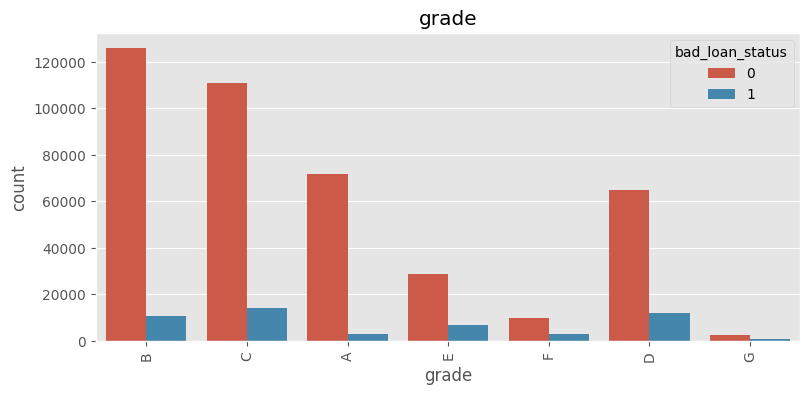

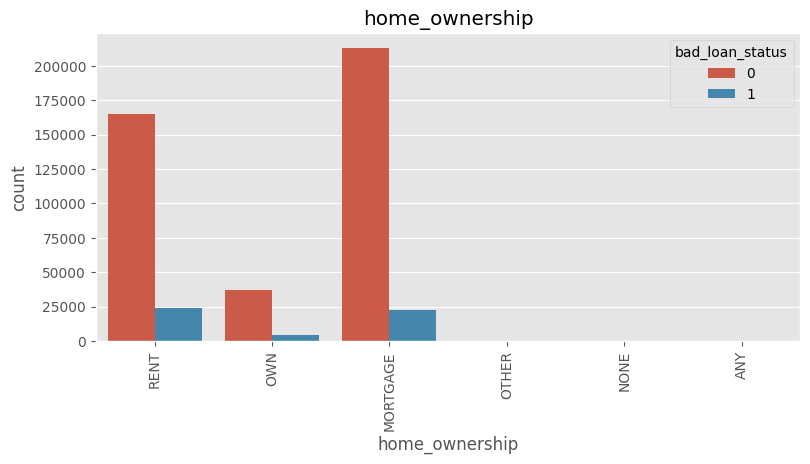

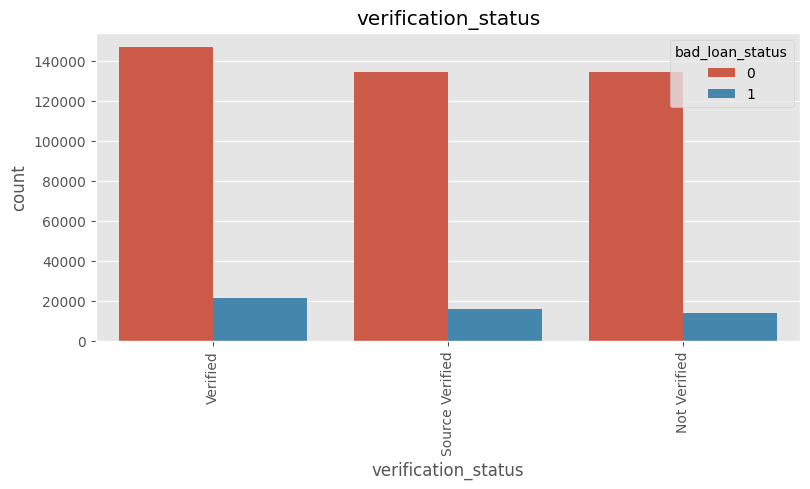

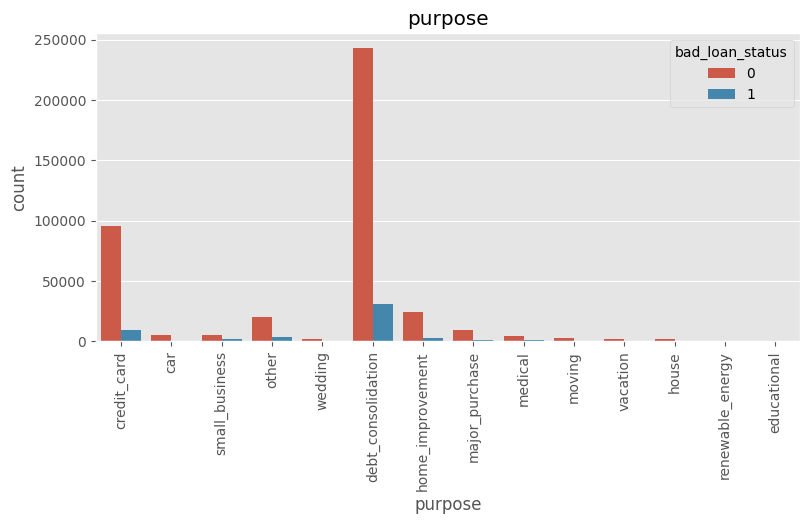

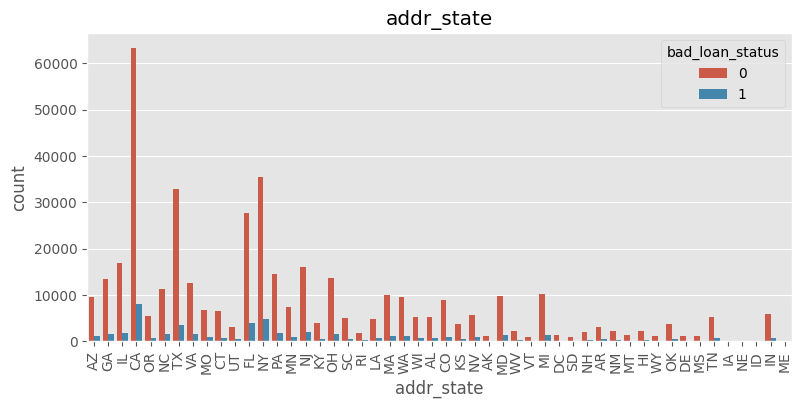

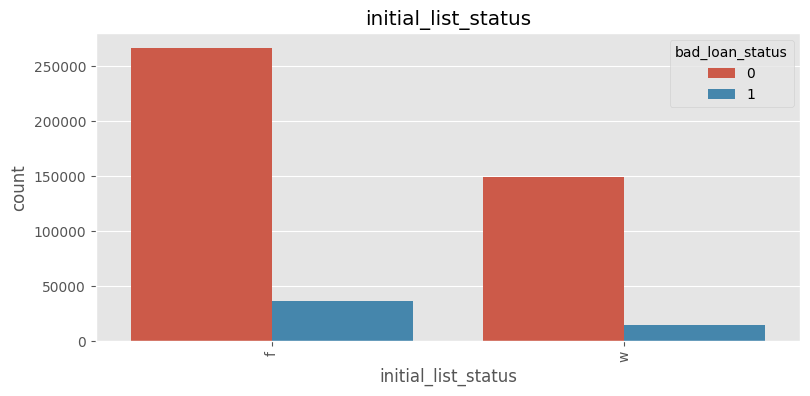

In [ ]:
plt.style.use("ggplot")
for column in categorical_var:
  plt.figure(figsize=(20,4))
  plt.subplot(1,2,1)
  sns.countplot(x=df[column], hue=df['bad_loan_status'])
  plt.title(column)
  plt.xticks(rotation=90)

# Data Preprocessing

##Cek Missing Value

In [ ]:
#Menghitung presentase missing value
cek_missing_values = df.isnull().sum() * 100 / df.shape[0]
print(cek_missing_values)

loan_amnt                         0.000000
funded_amnt                       0.000000
funded_amnt_inv                   0.000000
int_rate                          0.000000
installment                       0.000000
grade                             0.000000
home_ownership                    0.000000
annual_inc                        0.000858
verification_status               0.000000
purpose                           0.000000
addr_state                        0.000000
dti                               0.000000
delinq_2yrs                       0.006219
inq_last_6mths                    0.006219
mths_since_last_delinq           53.690554
mths_since_last_record           86.566585
open_acc                          0.006219
pub_rec                           0.006219
revol_bal                         0.000000
revol_util                        0.072917
total_acc                         0.006219
initial_list_status               0.000000
out_prncp                         0.000000
out_prncp_i

In [ ]:
#Memilih Fitur yang memiliki Missing Value
missing_values = cek_missing_values[cek_missing_values > 0].sort_values(ascending=False)
print(missing_values)

mths_since_last_record           86.566585
mths_since_last_delinq           53.690554
mths_since_next_pymnt_d          48.728567
emp_length_int                    4.505399
mths_since_last_pymnt_d           0.080637
revol_util                        0.072917
collections_12_mths_ex_med        0.031097
mths_since_last_credit_pull_d     0.009007
delinq_2yrs                       0.006219
pub_rec                           0.006219
inq_last_6mths                    0.006219
open_acc                          0.006219
acc_now_delinq                    0.006219
total_acc                         0.006219
mths_since_earliest_cr_line       0.006219
annual_inc                        0.000858
dtype: float64


In [ ]:
#Menghapus fitur yang memiliki missing value tinggi
df.drop(['mths_since_last_record','mths_since_next_pymnt_d', 'mths_since_last_pymnt_d'], axis=1, inplace=True)

In [ ]:
#Mengecek Kembali
cek_missing_values = (df.isnull().sum() * 100 / df.shape[0] )
missing_values = cek_missing_values[cek_missing_values > 0].sort_values(ascending=False)
print(missing_values)

mths_since_last_delinq           53.690554
emp_length_int                    4.505399
revol_util                        0.072917
collections_12_mths_ex_med        0.031097
mths_since_last_credit_pull_d     0.009007
total_acc                         0.006219
open_acc                          0.006219
delinq_2yrs                       0.006219
inq_last_6mths                    0.006219
acc_now_delinq                    0.006219
pub_rec                           0.006219
mths_since_earliest_cr_line       0.006219
annual_inc                        0.000858
dtype: float64


##Data imputation

In [ ]:
df['mths_since_last_delinq'].fillna(-1, inplace=True),
df['emp_length_int'].fillna(0, inplace=True),
df['revol_util'].fillna(0, inplace=True),
df['collections_12_mths_ex_med'].fillna(0, inplace=True),
df['mths_since_last_credit_pull_d'].fillna(0, inplace=True),
df['delinq_2yrs'].fillna(0, inplace=True),
df['pub_rec'].fillna(0, inplace=True),
df['inq_last_6mths'].fillna(0, inplace=True),
df['open_acc'].fillna(0, inplace=True),
df['acc_now_delinq'].fillna(0, inplace=True),
df['total_acc'].fillna(0, inplace=True),
df['mths_since_earliest_cr_line'].fillna(0, inplace=True),
df['annual_inc'].fillna(df['annual_inc'].median(), inplace=True)

/tmp/ipython-input-208883632.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mths_since_last_delinq'].fillna(-1, inplace=True),
/tmp/ipython-input-208883632.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

##Label Encoding

In [ ]:
#Import Sklearn
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

for column in categorical_var:
  df[column] = label.fit_transform(df[column])

#Menampilkan data
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,grade,home_ownership,annual_inc,verification_status,purpose,...,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,acc_now_delinq,bad_loan_status,emp_length_int,term_int,mths_since_earliest_cr_line,mths_since_issue_d,mths_since_last_credit_pull_d
0,5000,5000,4975.0,10.65,162.87,1,5,24000.0,2,1,...,0.00,171.62,0.0,0.0,0,10.0,36.0,395.0,72,23.0
1,2500,2500,2500.0,15.27,59.83,2,5,30000.0,1,0,...,1.11,119.66,0.0,0.0,1,1.0,60.0,224.0,72,51.0
2,2400,2400,2400.0,15.96,84.33,2,5,12252.0,0,11,...,0.00,649.91,0.0,0.0,0,10.0,36.0,193.0,72,23.0
3,10000,10000,10000.0,13.49,339.31,2,5,49200.0,1,9,...,0.00,357.48,0.0,0.0,0,10.0,36.0,262.0,72,35.0
4,3000,3000,3000.0,12.69,67.79,1,5,80000.0,1,9,...,0.00,67.79,0.0,0.0,0,1.0,60.0,263.0,72,23.0


## Mengatasi Imbalance Data

In [ ]:
from re import X
#Handling Imbalance Data
from imblearn.over_sampling import SMOTE

#memisahkan fitur (X) dan target (y)
X = df.drop('bad_loan_status', axis=1)
y = df['bad_loan_status']

#melakukan oversampling menggunakan SMOTE
oversampling = SMOTE(random_state=42, sampling_strategy=1)

In [ ]:
#Fit Oversampling
X, y = oversampling.fit_resample(X, y)

In [ ]:
#Melihat jumlah nilai y
y.value_counts()

,count
bad_loan_status,
0,415317
1,415317


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830634 entries, 0 to 830633
Data columns (total 38 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   loan_amnt                      830634 non-null  int64  
 1   funded_amnt                    830634 non-null  int64  
 2   funded_amnt_inv                830634 non-null  float64
 3   int_rate                       830634 non-null  float64
 4   installment                    830634 non-null  float64
 5   grade                          830634 non-null  int64  
 6   home_ownership                 830634 non-null  int64  
 7   annual_inc                     830634 non-null  float64
 8   verification_status            830634 non-null  int64  
 9   purpose                        830634 non-null  int64  
 10  addr_state                     830634 non-null  int64  
 11  dti                            830634 non-null  float64
 12  delinq_2yrs                   

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

#Membagi data pelatihan dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Menampilkan Jumlah baris, Kolom dari data pelatihan dan data uji
print("Jumlah baris dan kolom dari data pelatihan:", X_train.shape)
print("Jumlah baris dan kolom dari data uji:", X_test.shape)

Jumlah baris dan kolom dari data pelatihan: (664507, 38)
Jumlah baris dan kolom dari data uji: (166127, 38)


##Standarisasi

In [ ]:
from sklearn.preprocessing import StandardScaler

#Standarisasi data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
#Setelah dilakukan standarisasi
X_train_scaled.head()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,grade,home_ownership,annual_inc,verification_status,purpose,...,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,acc_now_delinq,emp_length_int,term_int,mths_since_earliest_cr_line,mths_since_issue_d,mths_since_last_credit_pull_d
0,-0.651285,-0.649094,-0.635161,-0.736161,-0.570413,-0.734466,-1.04829,-0.155130,-1.213341,-0.717352,...,-0.366413,-0.251715,-0.377167,-0.089591,-0.061947,0.678438,-0.693296,0.947405,-0.822061,-0.559226
1,-0.290114,-0.287353,-0.274810,-0.028793,-0.090266,0.063400,-1.04829,-0.194979,0.051116,-0.284493,...,-0.366413,-0.251715,-0.350596,-0.089591,-0.061947,1.268002,-0.693296,0.659412,-0.678864,-0.559226
2,-0.152267,-0.149288,-0.154434,0.103203,-0.279745,-0.734466,-1.04829,-0.070254,0.051116,-0.284493,...,0.341748,0.614162,-0.361081,-0.089591,-0.061947,0.764115,0.596778,-0.272615,1.325898,0.086253
3,-1.072652,-1.071126,-1.055570,-0.898117,-1.055182,-0.734466,-1.04829,0.111862,-1.213341,-0.284493,...,-0.366413,-0.251715,-0.403994,-0.089591,-0.061947,1.268002,-0.693296,0.183598,-0.750462,-0.559226
4,2.253255,2.260032,2.262835,-0.515712,2.781518,-0.734466,-1.04829,0.803777,1.315574,-0.717352,...,-0.366413,-0.251715,-0.191672,-0.089591,-0.061947,1.268002,-0.693296,0.385878,-0.750462,-0.559226


# Data Modeling dan Evaluasi

##Logistic Regression

### Model

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_train_pred = logreg.predict(X_train_scaled)
y_test_pred = logreg.predict(X_test)

###Evaluasi

ROC-AUC

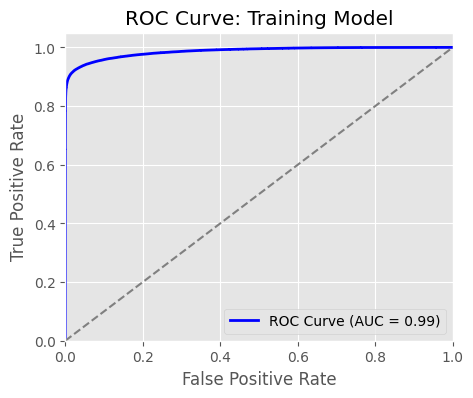

In [ ]:
#Training Model
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt

#Prediksi probabilitas untuk test set
y_prob = logreg.predict_proba(X_test_scaled)[:, 1]

#Menghitung ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

#Plot ROC Curve
# Plot the ROC curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Training Model')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Evaluasi di TEST SET
print("=== Evaluation on Test Set ===")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

=== Evaluation on Test Set ===
Accuracy : 0.8006043569076671
Precision: 0.7291599687686584
Recall   : 0.9561551433389545
F1 Score : 0.8273705604919613
ROC-AUC  : 0.9859499713194053

Confusion Matrix:
[[53622 29485]
 [ 3640 79380]]


##Random Forest

###Modeling

In [ ]:
#Model Random Forest
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi model dengan 100 pohon
rf_model = RandomForestClassifier(n_estimators=100, random_state=1)
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_model.predict(X_test)

### Evaluasi

In [ ]:
# Import metrics untuk evaluasi
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Evaluasi Model Random Forest
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='binary'))  # kalau binary classification
print("Recall:", recall_score(y_test, y_pred_rf, average='binary'))
print("F1-Score:", f1_score(y_test, y_pred_rf, average='binary'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.9897307481625504
Precision: 0.997698616721753
Recall: 0.9817152493375091
F1-Score: 0.989642401797098

Confusion Matrix:
[[82919   188]
 [ 1518 81502]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     83107
           1       1.00      0.98      0.99     83020

    accuracy                           0.99    166127
   macro avg       0.99      0.99      0.99    166127
weighted avg       0.99      0.99      0.99    166127

